Replica de articulo https://www.quantconnect.com/research/18987/portfolio-construction-using-topological-data-analysis/p1 

# Librerías

In [1]:
import pandas as pd
import numpy as np
import random

import plotly
import requests
from bs4 import BeautifulSoup
import ruptures as rpt
import yfinance as yf

import plotly.graph_objects as go
import matplotlib.pyplot as plt

import kmapper as km
import subprocess
import sys
import networkx as nx
subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "nbformat>=4.2.0"])
import sklearn.cluster

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.cluster import DBSCAN, KMeans
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots


In [2]:
# =======================================================
# 📊 CARGAR TICKERS DEL ARCHIVO GENERADO
# =======================================================

import os

tickers_filename = 'tickers_S&P.csv'

if os.path.exists(tickers_filename):
    print("✅ Archivo 'tickers_S&P.csv' encontrado")
    print("📂 Cargando tickers desde archivo...")
    print("=" * 80)
    
    tickers_df = pd.read_csv(tickers_filename)
    
    if 'Symbol' in tickers_df.columns:
        tickers = tickers_df['Symbol'].tolist()
        # Reemplazar "." por "-"
        tickers = [ticker.replace('.', '-') for ticker in tickers]
        print(f"✅ Tickers cargados: {len(tickers)}")
        print(f"   Primeros 10 tickers: {tickers[:10]}")
    else:
        print(f"❌ Error: Columna 'Symbol' no encontrada")
        raise ValueError("Formato de archivo incorrecto")
    
    if 'Weight' in tickers_df.columns:
        weights = tickers_df['Weight'].tolist()
        print(f"   Pesos disponibles: {len(weights)}")
else:
    print(f"❌ ERROR: Archivo '{tickers_filename}' no encontrado")
    print("   Por favor, ejecuta primero el notebook 'Mapper_500_Creación.ipynb'")
    raise FileNotFoundError(f"'{tickers_filename}' no encontrado en la carpeta actual")

print("=" * 80)

✅ Archivo 'tickers_S&P.csv' encontrado
📂 Cargando tickers desde archivo...
✅ Tickers cargados: 503
   Primeros 10 tickers: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META', 'TSLA', 'BRK-B']
   Pesos disponibles: 503


## Configuración de Fechas y Versión del Mapper

In [3]:
# =======================================================
# 🔧 CONFIGURACIÓN: FECHAS Y VERSIÓN DEL MAPPER
# =======================================================


# 📅 Definir fechas del análisisprint("=" * 80)

# Estas fechas deben coincidir con los archivos generados en Mapper_500_Creación.ipynb    print(f"   Usando versión: v{MAPPER_VERSION}")

START_DATE = '2022-01-01'  # Inicio del período completoelse:

END_DATE = '2025-11-01'    # Fin del período completo    print(f"   Usando archivo base (sin versión)")

AN_DATE = '2024-01-01'     # Fecha de división análisis/validaciónif MAPPER_VERSION is None:

print(f"\n🗂️ VERSIÓN DEL MAPPER:")

# 🗂️ Versión del mapper a usar (opcional)print(f"   División análisis/validación: {AN_DATE}")

# Deja en None para usar el archivo base sin versiónprint(f"   Período completo: {START_DATE} a {END_DATE}")

# O especifica un número para usar una versión específica (ej: 1, 2, 3)print("📅 CONFIGURACIÓN DE FECHAS:")

MAPPER_VERSION = 7  # None para base, o número para _v{número}print("=" * 80)



🗂️ VERSIÓN DEL MAPPER:


In [4]:
# =======================================================
# 📊 CARGAR HISTÓRICOS DEL ARCHIVO GENERADO - S&P 500
# =======================================================

historicos_filename = f'historicos_SP500_{START_DATE}_to_{END_DATE}.csv'

if os.path.exists(historicos_filename):
    print("✅ Archivo de históricos encontrado")
    print(f"📂 Cargando datos desde '{historicos_filename}'...")
    all_tickers_data = pd.read_csv(historicos_filename, index_col=0, parse_dates=True)
    all_tickers_data.index = pd.to_datetime(all_tickers_data.index)
    print(f"   Datos cargados: {all_tickers_data.shape}")
else:
    print(f"❌ ERROR: Archivo '{historicos_filename}' no encontrado")
    print("   Por favor, ejecuta primero el notebook 'Mapper_500_Creación.ipynb'")
    print(f"   Con las fechas: {START_DATE} a {END_DATE}")
    raise FileNotFoundError(f"'{historicos_filename}' no encontrado")

# Dividir en dos períodos
tickers_data = all_tickers_data.loc[START_DATE:AN_DATE]  # Análisis
validation_data = all_tickers_data.loc[AN_DATE:END_DATE]  # Validación

# Diagnóstico
tickers_descargados = set(all_tickers_data.columns)
tickers_faltantes = set(tickers) - tickers_descargados

print(f"\n✅ Resumen:")
print(f"   📊 Total: {all_tickers_data.shape}")
print(f"   📊 Análisis: {tickers_data.shape} ({START_DATE} a {AN_DATE})")
print(f"   📊 Validación: {validation_data.shape} ({AN_DATE} a {END_DATE})")
print(f"   ✅ Tickers disponibles: {len(tickers_descargados)}")
print(f"   ❌ Tickers faltantes: {len(tickers_faltantes)}")
if tickers_faltantes:
    print(f"      {', '.join(sorted(list(tickers_faltantes))[:20])}{'...' if len(tickers_faltantes) > 20 else ''}")
print("=" * 80)

✅ Archivo de históricos encontrado
📂 Cargando datos desde 'historicos_SP500_2022-01-01_to_2025-11-01.csv'...
   Datos cargados: (962, 495)

✅ Resumen:
   📊 Total: (962, 495)
   📊 Análisis: (501, 495) (2022-01-01 a 2024-01-01)
   📊 Validación: (461, 495) (2024-01-01 a 2025-11-01)
   ✅ Tickers disponibles: 495
   ❌ Tickers faltantes: 8
      CEG, GEHC, GEV, KVUE, Q, SOLS, SOLV, VLTO


In [5]:
# =======================================================
# 📊 CARGAR HISTÓRICOS DEL ARCHIVO GENERADO - SPY
# =======================================================

spy_filename = f'historicos_SPY_{START_DATE}_{END_DATE}.csv'

if os.path.exists(spy_filename):
    print(f"✅ Archivo '{spy_filename}' encontrado")
    SPY = pd.read_csv(spy_filename, index_col=0, parse_dates=True)
    SPY.index = pd.to_datetime(SPY.index)
else:
    print(f"❌ ERROR: Archivo '{spy_filename}' no encontrado")
    print("   Por favor, ejecuta primero el notebook 'Mapper_500_Creación.ipynb'")
    print(f"   Con las fechas: {START_DATE} a {END_DATE}")
    raise FileNotFoundError(f"'{spy_filename}' no encontrado")

# Dividir en períodos
SPY_analysis = SPY.loc[START_DATE:AN_DATE]
SPY_validation = SPY.loc[AN_DATE:END_DATE]

print(f"✅ SPY listo: {SPY.shape}")

print(f"   📊 Análisis: {SPY_analysis.shape}")
print("=" * 80)
print(f"   📊 Validación: {SPY_validation.shape}")

✅ Archivo 'historicos_SPY_2022-01-01_2025-11-01.csv' encontrado
✅ SPY listo: (962, 1)
   📊 Análisis: (501, 1)
   📊 Validación: (461, 1)


## Info financiera

In [6]:
from datetime import timedelta
import pandas as pd

def marketcap_en_fecha(ticker, fecha):
    # Convert string to datetime if needed
    if isinstance(fecha, str):
        fecha = pd.to_datetime(fecha)
    
    t = yf.Ticker(ticker)
    
    # Use a wider date range to ensure data availability
    fecha_inicio = fecha - timedelta(days=7)  # Look back 7 days
    
    # Get historical data
    history = t.history(start=fecha_inicio, end=fecha)
    shares = t.get_shares_full(start=fecha_inicio, end=fecha)
    
    # Validate data exists
    if history.empty or 'Close' not in history.columns:
        raise ValueError(f"No price data for {ticker} around {fecha}")
    if shares.empty:
        raise ValueError(f"No shares data for {ticker} around {fecha}")
    
    # Get the closest available data to the target date
    price = history["Close"].iloc[-1]  # Most recent price
    shares_count = shares.iloc[-1]     # Most recent share count
    
    return price * shares_count

# Example usage
marketcap_en_fecha("AVGO", AN_DATE)

51197756419.65918

In [7]:
# =======================================================
# 📊 CARGAR INFORMACIÓN FUNDAMENTAL DESDE ARCHIVO
# =======================================================

csv_filename = 'sp500_ticker_info_database.csv'

if os.path.exists(csv_filename):
    print("✅ Archivo 'sp500_ticker_info_database.csv' encontrado")
    print("📂 Cargando información desde archivo...")
    print("=" * 80)
    
    ticker_info_df = pd.read_csv(csv_filename, index_col=0)
    ticker_info_db = ticker_info_df.to_dict('index')
    
    print(f"✅ Datos cargados exitosamente")
    print(f"   📊 Total de tickers: {len(ticker_info_df)}")
    print(f"   📋 Columnas: {len(ticker_info_df.columns)}")
    print("=" * 80)
else:
    print(f"❌ ERROR: Archivo '{csv_filename}' no encontrado")
    print("   Por favor, ejecuta primero el notebook 'Mapper_500_Creación.ipynb'")
    raise FileNotFoundError(f"'{csv_filename}' no encontrado")

# Mostrar primeras filas
print("\n📋 Primeras filas de la base de datos:")
display(ticker_info_df.head())

✅ Archivo 'sp500_ticker_info_database.csv' encontrado
📂 Cargando información desde archivo...
✅ Datos cargados exitosamente
   📊 Total de tickers: 503
   📋 Columnas: 5

📋 Primeras filas de la base de datos:


,sector,industry,market_cap,country,full_name
NVDA,Technology,Semiconductors,1.222580e+11,United States,NVIDIA Corporation
AAPL,Technology,Consumer Electronics,2.966366e+12,United States,Apple Inc.
MSFT,Technology,Software - Infrastructure,2.758923e+12,United States,Microsoft Corporation
AMZN,Consumer Cyclical,Internet Retail,1.570148e+12,United States,"Amazon.com, Inc."
GOOGL,Communication Services,Internet Content & Information,1.743543e+12,United States,Alphabet Inc.


## Cargar Grafo del Mapper Generado

In [8]:
# =======================================================
# 📊 CARGAR GRAFO DESDE MAPPER_500_CREACIÓN
# =======================================================

import glob
import re

print("=" * 80)
print("🔍 BUSCANDO ARCHIVO DE MAPPER GENERADO")
print("=" * 80)

# Construir nombre del archivo mapper basado en fechas y versión
base_filename = f"mapper_portfolio_{START_DATE}_to_{AN_DATE}"

if MAPPER_VERSION is None:
    # Buscar archivo base sin versión
    mapper_file = f"{base_filename}.html"
    if not os.path.exists(mapper_file):
        # Si no existe el base, buscar el más reciente
        pattern = f"{base_filename}*.html"
        existing_files = glob.glob(pattern)
        if existing_files:
            # Encontrar el de mayor versión
            max_version = 0
            max_file = None
            for file in existing_files:
                match = re.search(r'_v(\d+)\.html$', file)
                if match:
                    version = int(match.group(1))
                    if version > max_version:
                        max_version = version
                        max_file = file
            mapper_file = max_file if max_file else existing_files[0]
            print(f"⚠️  Archivo base no encontrado, usando: {mapper_file}")
        else:
            print(f"❌ ERROR: No se encontró ningún archivo mapper con las fechas especificadas")
            print(f"   Patrón buscado: {pattern}")
            print(f"   Por favor, ejecuta primero 'Mapper_500_Creación.ipynb'")
            raise FileNotFoundError(f"No se encontró archivo mapper para {START_DATE} a {AN_DATE}")
else:
    # Usar versión específica
    mapper_file = f"{base_filename}_v{MAPPER_VERSION}.html"
    if not os.path.exists(mapper_file):
        print(f"❌ ERROR: Archivo específico no encontrado: {mapper_file}")
        pattern = f"{base_filename}*.html"
        existing_files = glob.glob(pattern)
        if existing_files:
            print(f"\\n📁 Archivos disponibles:")
            for file in existing_files:
                print(f"   - {file}")
        raise FileNotFoundError(f"'{mapper_file}' no encontrado")

print(f"✅ Archivo encontrado: {mapper_file}")

# NOTA: El archivo HTML del mapper contiene el grafo pero en formato JSON embebido
# Para este notebook, asumimos que ya tenemos acceso al grafo a través de 
# la ejecución previa del notebook Mapper_500_Creación.ipynb

# Verificar que el archivo existe
if os.path.exists(mapper_file):
    print(f"✅ Mapper HTML verificado: {mapper_file}")
    print(f"   Tamaño: {os.path.getsize(mapper_file) / 1024:.2f} KB")
    print(f"\\n⚠️  IMPORTANTE:")
    print(f"   Este notebook asume que tienes el grafo 'graph' y 'node_clusters'")
    print(f"   cargados en memoria desde Mapper_500_Creación.ipynb")
    print(f"   Si no los tienes, ejecuta primero ese notebook completo.")
else:
    raise FileNotFoundError(f"'{mapper_file}' no encontrado")

print("=" * 80)

🔍 BUSCANDO ARCHIVO DE MAPPER GENERADO
✅ Archivo encontrado: mapper_portfolio_2022-01-01_to_2024-01-01_v7.html
✅ Mapper HTML verificado: mapper_portfolio_2022-01-01_to_2024-01-01_v7.html
   Tamaño: 61.64 KB
\n⚠️  IMPORTANTE:
   Este notebook asume que tienes el grafo 'graph' y 'node_clusters'
   cargados en memoria desde Mapper_500_Creación.ipynb
   Si no los tienes, ejecuta primero ese notebook completo.


## Metricas

In [9]:
# Sacamos métricas de cada ticker

financial_metrics = {}
print("\n🔄 Calculando métricas financieras...")
for ticker in tickers_data.columns:
    try:
        prices = tickers_data[ticker].dropna()
        returns = prices.pct_change().dropna()
        
        # Métricas básicas
        total_return = (prices.iloc[-1] / prices.iloc[0]) - 1
        volatility = returns.std() * np.sqrt(252)  # Anualizada
        sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
        
        # Métricas de riesgo
        max_drawdown = ((prices / prices.cummax()) - 1).min()
        var_95 = returns.quantile(0.05)  # Value at Risk 95%
        skewness = returns.skew()
        kurtosis = returns.kurtosis()
        
        # Métricas de tendencia
        returns_positive_ratio = (returns > 0).mean()
        trend_slope = np.polyfit(range(len(prices)), prices.values, 1)[0]
        
        financial_metrics[ticker] = {
            'total_return': total_return,
            'volatility': volatility,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_drawdown,
            'var_95': var_95,
            'skewness': skewness,
            'kurtosis': kurtosis,
            'positive_ratio': returns_positive_ratio,
            'trend_slope': trend_slope / prices.iloc[0]  # Normalizado
        }
    except Exception as e:
        print(f"❌ Error procesando {ticker}: {e}")

# Convertir a DataFrame
metrics_df = pd.DataFrame(financial_metrics).T

# Normalizar datos
scaler = StandardScaler()
metrics_scaled = scaler.fit_transform(metrics_df.fillna(0))# Datos normalizados que ya tenemos

# Preparar datos para KeplerMapper (usar métricas financieras)

ticker_names = metrics_df.index.tolist()


print(f"📊 Datos preparados: {metrics_scaled.shape[0]} tickers, {metrics_scaled.shape[1]} métricas")


🔄 Calculando métricas financieras...
📊 Datos preparados: 495 tickers, 9 métricas
📊 Datos preparados: 495 tickers, 9 métricas


# Cargar Grafo desde Mapper_500_Creación.ipynb

In [10]:
# =======================================================
# 📦 CARGAR GRAFO Y CLUSTERS DESDE ARCHIVO PICKLE
# =======================================================

import pickle

print("=" * 80)
print("📦 CARGANDO GRAFO Y CLUSTERS DESDE ARCHIVO PICKLE")
print("=" * 80)

# Generar nombre de archivo pickle basado en fechas
pickle_filename = f"mapper_graph_{START_DATE}_to_{AN_DATE}_v{MAPPER_VERSION}.pkl"

if os.path.exists(pickle_filename):
    print(f"✅ Archivo encontrado: {pickle_filename}")
    print(f"📂 Cargando datos...")
    
    with open(pickle_filename, 'rb') as f:
        data = pickle.load(f)
    
    # Extraer variables
    graph = data['graph']
    node_clusters = data['node_clusters']
    available_tickers = data['available_tickers']
    
    # Verificar fechas
    if data['START_DATE'] != START_DATE or data['AN_DATE'] != AN_DATE:
        print(f"\n⚠️  ADVERTENCIA: Las fechas del archivo no coinciden!")
        print(f"   Archivo: {data['START_DATE']} a {data['AN_DATE']}")
        print(f"   Configuradas: {START_DATE} a {AN_DATE}")
        print(f"   Continuando de todas formas...")
    
    print(f"\n✅ Datos cargados exitosamente:")
    print(f"   📊 graph: {len(graph['nodes'])} nodos, {len(graph['links'])} enlaces")
    print(f"   📊 node_clusters: {len(node_clusters)} clusters")
    print(f"   📊 available_tickers: {len(available_tickers)} tickers")
    print(f"   📅 Fechas del archivo: {data['START_DATE']} a {data['END_DATE']}")
    
    # Mostrar algunos clusters de ejemplo
    cluster_sizes = [len(members) for members in node_clusters.values()]
    print(f"\n📋 Estadísticas de clusters:")
    print(f"   Tamaño promedio: {np.mean(cluster_sizes):.1f} tickers")
    print(f"   Tamaño mínimo: {np.min(cluster_sizes)} tickers")
    print(f"   Tamaño máximo: {np.max(cluster_sizes)} tickers")
    
    print(f"\n📋 Clusters:")
    for i, (cluster_id, members) in enumerate(list(node_clusters.items()), 1):
        print(f"   {i}. Cluster {cluster_id}: {len(members)} tickers - {members[:5]}{'...' if len(members) > 5 else ''}")

else:
    print(f"❌ ERROR: Archivo no encontrado: {pickle_filename}")
    print(f"\n⚠️  SOLUCIÓN:")
    print(f"   1. Abre 'Mapper_500_Creación.ipynb'")
    print(f"   2. Configura las mismas fechas:")
    print(f"      START_DATE = '{START_DATE}'")
    print(f"      END_DATE = '{END_DATE}'")
    print(f"      AN_DATE = '{AN_DATE}'")
    print(f"   3. Ejecuta TODO el notebook hasta el final")
    print(f"   4. Vuelve aquí y ejecuta esta celda nuevamente")
    raise FileNotFoundError(f"'{pickle_filename}' no encontrado")

print("=" * 80)

📦 CARGANDO GRAFO Y CLUSTERS DESDE ARCHIVO PICKLE
✅ Archivo encontrado: mapper_graph_2022-01-01_to_2024-01-01_v7.pkl
📂 Cargando datos...

✅ Datos cargados exitosamente:
   📊 graph: 11 nodos, 7 enlaces
   📊 node_clusters: 11 clusters
   📊 available_tickers: 495 tickers
   📅 Fechas del archivo: 2022-01-01 a 2025-11-01

📋 Estadísticas de clusters:
   Tamaño promedio: 55.1 tickers
   Tamaño mínimo: 7 tickers
   Tamaño máximo: 134 tickers

📋 Clusters:
   1. Cluster cube0_cluster0: 38 tickers - ['AMAT', 'AMD', 'AMT', 'ARE', 'AVB']...
   2. Cluster cube1_cluster0: 53 tickers - ['ADI', 'ALB', 'AMAT', 'AMD', 'AMP']...
   3. Cluster cube2_cluster0: 83 tickers - ['ACGL', 'ADSK', 'AFL', 'AIG', 'AIZ']...
   4. Cluster cube3_cluster0: 115 tickers - ['AAPL', 'ABNB', 'ACN', 'ADBE', 'ADSK']...
   5. Cluster cube4_cluster0: 134 tickers - ['ADP', 'AJG', 'AKAM', 'ALLE', 'AMCR']...
   6. Cluster cube5_cluster0: 77 tickers - ['A', 'ABT', 'ADP', 'AJG', 'AKAM']...
   7. Cluster cube6_cluster0: 33 tickers - ['B

# Modelo

## Reducción de portafolio

In [11]:
# =======================================================
# 📊 PASO 5A: REDUCCIÓN DE PORTAFOLIO - SELECCIÓN DE REPRESENTANTES
# =======================================================

print("\n" + "="*80)
print("✂️  REDUCCIÓN DE PORTAFOLIO - SELECCIÓN DE REPRESENTANTES POR CLUSTER")
print("="*80)

def select_cluster_representatives(clusters_dict, metrics_dict, ticker_info, 
                                   n_per_cluster=1, selection_method='combined'):
    """
    Selecciona los tickers más representativos de cada cluster.
    
    Parámetros:
    -----------
    clusters_dict : dict
        {cluster_id: [lista de tickers]}
    metrics_dict : dict
        {ticker: {'sharpe_ratio': ..., 'volatility': ..., etc}}
    ticker_info : dict
        {ticker: {'market_cap': ..., 'sector': ..., etc}}
    n_per_cluster : int
        Número de tickers a seleccionar por cluster (default: 1)
    selection_method : str
        'sharpe' - Mejor Sharpe Ratio
        'market_cap' - Mayor capitalización
        'volatility' - Menor volatilidad
        'combined' - Combinación de Sharpe + Market Cap (RECOMENDADO)
    
    Returns:
    --------
    selected_tickers : list
        Lista de tickers seleccionados
    cluster_info : dict
        Información de selección por cluster
    """
    selected_tickers = []
    cluster_selection_info = {}
    
    print(f"🔧 Método de selección: {selection_method}")
    print(f"📊 Tickers por cluster: {n_per_cluster}")
    print(f"\n📋 Seleccionando representantes...")
    
    for cluster_id, tickers in clusters_dict.items():
        if len(tickers) == 0:
            continue
        
        # Calcular scores para cada ticker
        ticker_scores = []
        for ticker in tickers:
            metrics = metrics_dict.get(ticker, {})
            info = ticker_info.get(ticker, {})
            
            sharpe = metrics.get('sharpe_ratio', 0)
            volatility = metrics.get('volatility', 1)
            market_cap = info.get('market_cap', 0)
            
            if selection_method == 'sharpe':
                score = sharpe
            elif selection_method == 'market_cap':
                score = market_cap
            elif selection_method == 'volatility':
                score = -volatility  # Negativo porque queremos MENOR volatilidad
            elif selection_method == 'combined':
                # Normalizar y combinar (50% Sharpe, 50% Market Cap)
                # Usar ranking para evitar problemas de escala
                score = sharpe * 0.5 + (market_cap / 1e12) * 0.5 
            else:
                score = 0
            
            ticker_scores.append({
                'ticker': ticker,
                'score': score,
                'sharpe': sharpe,
                'volatility': volatility,
                'market_cap': market_cap
            })
        
        # Ordenar por score y seleccionar top N
        ticker_scores.sort(key=lambda x: x['score'], reverse=True)
        selected = ticker_scores[:n_per_cluster]
        
        # Guardar seleccionados
        for item in selected:
            selected_tickers.append(item['ticker'])
        
        # Guardar info del cluster
        cluster_selection_info[cluster_id] = {
            'total_tickers': len(tickers),
            'selected': [s['ticker'] for s in selected],
            'selected_info': selected
        }
        
        # Mostrar info de TODOS los seleccionados
        if len(selected) > 0:
            print(f"   Cluster {str(cluster_id):>10s} ({len(tickers):3d} tickers) → {len(selected)} seleccionado(s):")
            for i, sel_ticker in enumerate(selected, 1):
                print(f"      {i}. {sel_ticker['ticker']:5s} (Sharpe={sel_ticker['sharpe']:6.3f}, "
                      f"Vol={sel_ticker['volatility']*100:5.1f}%, MC=${sel_ticker['market_cap']/1e9:6.1f}B)")
    
    print(f"\n✅ Selección completada:")
    print(f"   📊 Tickers originales: {sum(len(t) for t in clusters_dict.values())}")
    print(f"   ✂️  Tickers seleccionados: {len(selected_tickers)}")
    print(f"   📉 Reducción: {(1 - len(selected_tickers)/sum(len(t) for t in clusters_dict.values()))*100:.1f}%")
    
    return selected_tickers, cluster_selection_info

# Preparar métricas en formato dict
financial_metrics_dict = metrics_df.to_dict('index')

# CONFIGURACIÓN DE REDUCCIÓN
N_REPRESENTATIVES = 1  # 🔧 CAMBIAR AQUÍ: 1, 2 o 3 tickers por cluster
SELECTION_METHOD = 'combined'  # 🔧 OPCIONES: 'sharpe', 'market_cap', 'volatility', 'combined'

# Aplicar selección de representantes
selected_tickers, cluster_info = select_cluster_representatives(
    node_clusters,
    financial_metrics_dict,
    ticker_info_db,
    n_per_cluster=N_REPRESENTATIVES,
    selection_method=SELECTION_METHOD
)

# Crear clusters reducidos (solo con representantes)
reduced_clusters = {
    cluster_id: info['selected'] 
    for cluster_id, info in cluster_info.items()
}

print("\n" + "="*80)


✂️  REDUCCIÓN DE PORTAFOLIO - SELECCIÓN DE REPRESENTANTES POR CLUSTER
🔧 Método de selección: combined
📊 Tickers por cluster: 1

📋 Seleccionando representantes...
   Cluster cube0_cluster0 ( 38 tickers) → 1 seleccionado(s):
      1. IRM   (Sharpe= 0.834, Vol= 29.4%, MC=$  19.4B)
   Cluster cube1_cluster0 ( 53 tickers) → 1 seleccionado(s):
      1. AVGO  (Sharpe= 1.003, Vol= 34.9%, MC=$  51.2B)
   Cluster cube2_cluster0 ( 83 tickers) → 1 seleccionado(s):
      1. ACGL  (Sharpe= 1.097, Vol= 26.7%, MC=$  26.4B)
   Cluster cube3_cluster0 (115 tickers) → 1 seleccionado(s):
      1. AAPL  (Sharpe= 0.262, Vol= 29.1%, MC=$2966.4B)
   Cluster cube4_cluster0 (134 tickers) → 1 seleccionado(s):
      1. FICO  (Sharpe= 1.399, Vol= 40.3%, MC=$  28.8B)
   Cluster cube5_cluster0 ( 77 tickers) → 1 seleccionado(s):
      1. FICO  (Sharpe= 1.399, Vol= 40.3%, MC=$  28.8B)
   Cluster cube6_cluster0 ( 33 tickers) → 1 seleccionado(s):
      1. HII   (Sharpe= 0.905, Vol= 24.3%, MC=$   9.9B)
   Cluster cube6_c

# Portafolio

In [12]:
# =======================================================
# 📊 PASO 6: CONSTRUCCIÓN DE PORTAFOLIO REDUCIDO - EQUAL CLUSTERS WEIGHTING
# =======================================================

print("\n" + "="*80)
print("💼 CONSTRUCCIÓN DE PORTAFOLIO REDUCIDO - EQUAL CLUSTERS WEIGHTING")
print("="*80)

def weight_distribution(clustered_symbols):
    """
    Asigna pesos iguales entre clusters y divide equitativamente dentro de cada cluster.
    
    Parámetros:
    -----------
    clustered_symbols : dict
        Diccionario con {cluster_id: [lista de símbolos]}
    
    Returns:
    --------
    weights : dict
        Diccionario con {símbolo: peso}
    """
    weights = {}
    num_clusters = len(clustered_symbols)
    
    if num_clusters == 0:
        return weights
    
    for cluster_id, symbols in clustered_symbols.items():
        if len(symbols) == 0:
            continue
            
        # Peso igual por cluster
        cluster_weight = 1.0 / num_clusters
        
        # Dividir peso del cluster entre sus símbolos
        symbol_weight = cluster_weight / len(symbols)
        
        for symbol in symbols:
            weights[symbol] = symbol_weight
    
    return weights

# Aplicar la distribución de pesos AL PORTAFOLIO REDUCIDO
portfolio_weights = weight_distribution(reduced_clusters)

print(f"🎯 COMPARACIÓN DE PORTAFOLIOS:")
print(f"   📊 Portafolio Original: {sum(len(c) for c in node_clusters.values())} tickers")
print(f"   ✂️  Portafolio Reducido: {len(portfolio_weights)} tickers")
print(f"   📉 Reducción: {(1 - len(portfolio_weights)/sum(len(c) for c in node_clusters.values()))*100:.1f}%")

print(f"✅ Pesos calculados para {len(portfolio_weights)} símbolos")
print(f"   Número de clusters: {len(node_clusters)}")
print(f"   Suma total de pesos: {sum(portfolio_weights.values()):.6f}")

# Estadísticas de pesos
weights_values = list(portfolio_weights.values())
print(f"\n📊 Estadísticas de pesos:")
print(f"   Peso promedio: {np.mean(weights_values):.4%}")
print(f"   Peso mínimo: {np.min(weights_values):.4%}")
print(f"   Peso máximo: {np.max(weights_values):.4%}")
print(f"   Desv. estándar: {np.std(weights_values):.4%}")

# Mostrar top 10 pesos
print(f"\n🔝 Top  tickers por peso:")
sorted_weights = sorted(portfolio_weights.items(), key=lambda x: x[1], reverse=True)
for i, (ticker, weight) in enumerate(sorted_weights, 1):
    cluster_id = [cid for cid, members in node_clusters.items() if ticker in members][0]
    cluster_size = len(node_clusters[cluster_id])
    print(f"   {i:2d}. {ticker:5s}: {weight:7.4%} (Cluster {cluster_id}, size={cluster_size})")

print("="*80)


💼 CONSTRUCCIÓN DE PORTAFOLIO REDUCIDO - EQUAL CLUSTERS WEIGHTING
🎯 COMPARACIÓN DE PORTAFOLIOS:
   📊 Portafolio Original: 606 tickers
   ✂️  Portafolio Reducido: 9 tickers
   📉 Reducción: 98.5%
✅ Pesos calculados para 9 símbolos
   Número de clusters: 11
   Suma total de pesos: 0.818182

📊 Estadísticas de pesos:
   Peso promedio: 9.0909%
   Peso mínimo: 9.0909%
   Peso máximo: 9.0909%
   Desv. estándar: 0.0000%

🔝 Top  tickers por peso:
    1. IRM  : 9.0909% (Cluster cube0_cluster0, size=38)
    2. AVGO : 9.0909% (Cluster cube1_cluster0, size=53)
    3. ACGL : 9.0909% (Cluster cube2_cluster0, size=83)
    4. AAPL : 9.0909% (Cluster cube3_cluster0, size=115)
    5. FICO : 9.0909% (Cluster cube4_cluster0, size=134)
    6. HII  : 9.0909% (Cluster cube6_cluster0, size=33)
    7. CAH  : 9.0909% (Cluster cube6_cluster1, size=10)
    8. PCG  : 9.0909% (Cluster cube8_cluster0, size=29)
    9. MPC  : 9.0909% (Cluster cube9_cluster0, size=27)


## redistribución de pesos

In [13]:
# =======================================================
# 🔍 DIAGNÓSTICO: VERIFICAR CLUSTERS Y TICKERS FALTANTES
# =======================================================

print("\n" + "="*80)
print("🔍 DIAGNÓSTICO: Clusters vs Tickers en Portafolio")
print("="*80)

# 1. Contar clusters
num_clusters = len(node_clusters)
print(f"\n📊 Número de clusters en node_clusters: {num_clusters}")

# 2. Contar tickers en portfolio_weights
num_tickers_portfolio = len(portfolio_weights)
print(f"📊 Número de tickers en portfolio_weights: {num_tickers_portfolio}")

# 3. Verificar suma de pesos
suma_pesos = sum(portfolio_weights.values())
print(f"📊 Suma de pesos en portfolio_weights: {suma_pesos:.6f}")
print(f"   {'✅ Correcto' if abs(suma_pesos - 1.0) < 0.001 else '❌ PROBLEMA: No suma 1.0!'}")

# 4. Mostrar peso individual esperado vs real
peso_esperado = 1.0 / num_clusters
peso_real_promedio = sum(portfolio_weights.values()) / len(portfolio_weights)
print(f"\n📊 Peso esperado por ticker (1/{num_clusters}): {peso_esperado:.6f} ({peso_esperado*100:.2f}%)")
print(f"📊 Peso real promedio: {peso_real_promedio:.6f} ({peso_real_promedio*100:.2f}%)")

# 5. Identificar clusters sin ticker
clusters_con_ticker = set()
for ticker in portfolio_weights.keys():
    for cid, members in node_clusters.items():
        if ticker in members:
            clusters_con_ticker.add(cid)
            break

clusters_sin_ticker = set(node_clusters.keys()) - clusters_con_ticker
print(f"\n📊 Clusters con ticker asignado: {len(clusters_con_ticker)}/{num_clusters}")
print(f"📊 Clusters SIN ticker asignado: {len(clusters_sin_ticker)}")

if clusters_sin_ticker:
    print(f"\n⚠️  CLUSTERS FALTANTES:")
    for cid in sorted(clusters_sin_ticker):
        print(f"   Cluster {cid}: {len(node_clusters[cid])} miembros - {list(node_clusters[cid])[:3]}...")

# 6. Verificar si los tickers del portafolio están en tickers_data
tickers_faltantes_en_data = [t for t in portfolio_weights.keys() if t not in tickers_data.columns]
if tickers_faltantes_en_data:
    print(f"\n⚠️  TICKERS EN PORTFOLIO PERO NO EN tickers_data:")
    for t in tickers_faltantes_en_data:
        print(f"   {t}")

print("\n" + "="*80)
print("💡 RECOMENDACIÓN:")
if clusters_sin_ticker:
    print("   Hay clusters sin ticker asignado. Esto causa que el portafolio no sume 100%.")
    print("   Solución: Ajustar pesos para que sumen exactamente 1.0")
    print(f"   Peso que falta: {(1.0 - suma_pesos)*100:.2f}%")
elif suma_pesos < 0.999:
    print(f"   Los pesos solo suman {suma_pesos:.4f} en lugar de 1.0")
    print(f"   Falta: {(1.0 - suma_pesos)*100:.2f}%")
else:
    print("   ✅ Todo correcto: Todos los clusters tienen ticker y los pesos suman 1.0")
print("="*80)


🔍 DIAGNÓSTICO: Clusters vs Tickers en Portafolio

📊 Número de clusters en node_clusters: 11
📊 Número de tickers en portfolio_weights: 9
📊 Suma de pesos en portfolio_weights: 0.818182
   ❌ PROBLEMA: No suma 1.0!

📊 Peso esperado por ticker (1/11): 0.090909 (9.09%)
📊 Peso real promedio: 0.090909 (9.09%)

📊 Clusters con ticker asignado: 9/11
📊 Clusters SIN ticker asignado: 2

⚠️  CLUSTERS FALTANTES:
   Cluster cube5_cluster0: 77 miembros - ['A', 'ABT', 'ADP']...
   Cluster cube7_cluster0: 7 miembros - ['GD', 'HII', 'LDOS']...

💡 RECOMENDACIÓN:
   Hay clusters sin ticker asignado. Esto causa que el portafolio no sume 100%.
   Solución: Ajustar pesos para que sumen exactamente 1.0
   Peso que falta: 18.18%


In [14]:
# =======================================================
# 🔧 CORRECCIÓN: NORMALIZAR PESOS PARA QUE SUMEN 1.0
# =======================================================

print("\n" + "="*80)
print("🔧 CORRECCIÓN: Normalizando pesos del portafolio")
print("="*80)

# Verificar suma actual
suma_original = sum(portfolio_weights.values())
print(f"\n📊 Suma de pesos ANTES de corrección: {suma_original:.6f}")

if abs(suma_original - 1.0) > 0.001:
    print(f"   ⚠️  Los pesos no suman 1.0, normalizando...")
    
    # Normalizar pesos para que sumen exactamente 1.0
    portfolio_weights_corrected = {
        ticker: peso / suma_original 
        for ticker, peso in portfolio_weights.items()
    }
    
    # Verificar
    suma_corregida = sum(portfolio_weights_corrected.values())
    print(f"📊 Suma de pesos DESPUÉS de corrección: {suma_corregida:.10f}")
    print(f"   ✅ Correcto!")
    
    # Mostrar diferencia
    print(f"\n📊 Comparación de pesos:")
    print(f"{'Ticker':<10} {'Peso Original (%)':<20} {'Peso Corregido (%)':<20} {'Diferencia':<15}")
    print("-"*70)
    for ticker in sorted(portfolio_weights.keys()):
        peso_orig = portfolio_weights[ticker] * 100
        peso_corr = portfolio_weights_corrected[ticker] * 100
        diff = peso_corr - peso_orig
        print(f"{ticker:<10} {peso_orig:>18.4f}% {peso_corr:>19.4f}% {diff:>+14.4f}%")
    
    # Reemplazar portfolio_weights con la versión corregida
    portfolio_weights = portfolio_weights_corrected
    print(f"\n✅ portfolio_weights actualizado con pesos normalizados")
    
else:
    print(f"   ✅ Los pesos ya suman 1.0, no se requiere corrección")

print("="*80)


🔧 CORRECCIÓN: Normalizando pesos del portafolio

📊 Suma de pesos ANTES de corrección: 0.818182
   ⚠️  Los pesos no suman 1.0, normalizando...
📊 Suma de pesos DESPUÉS de corrección: 1.0000000000
   ✅ Correcto!

📊 Comparación de pesos:
Ticker     Peso Original (%)    Peso Corregido (%)   Diferencia     
----------------------------------------------------------------------
AAPL                   9.0909%             11.1111%        +2.0202%
ACGL                   9.0909%             11.1111%        +2.0202%
AVGO                   9.0909%             11.1111%        +2.0202%
CAH                    9.0909%             11.1111%        +2.0202%
FICO                   9.0909%             11.1111%        +2.0202%
HII                    9.0909%             11.1111%        +2.0202%
IRM                    9.0909%             11.1111%        +2.0202%
MPC                    9.0909%             11.1111%        +2.0202%
PCG                    9.0909%             11.1111%        +2.0202%

✅ portfolio_

## Back testing

In [15]:
# =======================================================
# 📊 PASO 7: BACKTESTING - SIMULACIÓN DEL PORTAFOLIO
# =======================================================

print("\n" + "="*80)
print("📈 BACKTESTING - SIMULACIÓN DEL PORTAFOLIO TDA")
print("="*80)

# Usar datos del período de análisis
backtest_data = tickers_data[list(portfolio_weights.keys())].copy()

print(f"📊 Datos para backtest:")
print(f"   Tickers en portafolio: {len(portfolio_weights)}")
print(f"   Período: {backtest_data.index[0].strftime('%Y-%m-%d')} a {backtest_data.index[-1].strftime('%Y-%m-%d')}")
print(f"   Días de trading: {len(backtest_data)}")

# Calcular retornos diarios
daily_returns = backtest_data.pct_change().dropna()

# Calcular retorno del portafolio
weights_array = np.array([portfolio_weights[ticker] for ticker in daily_returns.columns])
portfolio_daily_returns = (daily_returns * weights_array).sum(axis=1)

# Calcular valor acumulado del portafolio (comenzando en 1)
portfolio_cumulative = (1 + portfolio_daily_returns).cumprod()

# Calcular SPY para comparación
spy_returns_analysis = SPY_analysis['SPY'].pct_change().dropna()
spy_cumulative = (1 + spy_returns_analysis).cumprod()

# Alinear índices
common_dates = portfolio_cumulative.index.intersection(spy_cumulative.index)
portfolio_cumulative = portfolio_cumulative[common_dates]
spy_cumulative = spy_cumulative[common_dates]

print(f"\n✅ Backtest completado")
print(f"   Valor final portafolio TDA: {portfolio_cumulative.iloc[-1]:.4f}")
print(f"   Valor final SPY: {spy_cumulative.iloc[-1]:.4f}")
print(f"   Diferencia: {((portfolio_cumulative.iloc[-1] / spy_cumulative.iloc[-1]) - 1) * 100:+.2f}%")

print("="*80)


📈 BACKTESTING - SIMULACIÓN DEL PORTAFOLIO TDA
📊 Datos para backtest:
   Tickers en portafolio: 9
   Período: 2022-01-03 a 2023-12-29
   Días de trading: 501

✅ Backtest completado
   Valor final portafolio TDA: 1.8153
   Valor final SPY: 1.0265
   Diferencia: +76.84%


In [16]:
# =======================================================
# 📊 PASO 8: MÉTRICAS DE PERFORMANCE
# =======================================================

print("\n" + "="*80)
print("📊 MÉTRICAS DE PERFORMANCE")
print("="*80)

def calculate_portfolio_metrics(returns, cumulative_value, name="Portfolio"):
    """Calcula métricas de performance de un portafolio"""
    
    # Retorno total
    total_return = (cumulative_value.iloc[-1] - 1) * 100
    
    # Retorno anualizado
    n_years = len(returns) / 252
    annualized_return = ((cumulative_value.iloc[-1]) ** (1/n_years) - 1) * 100
    
    # Volatilidad anualizada
    volatility = returns.std() * np.sqrt(252) * 100
    
    # Sharpe Ratio (asumiendo rf=0)
    sharpe = annualized_return / volatility if volatility > 0 else 0
    
    # Maximum Drawdown
    running_max = cumulative_value.cummax()
    drawdown = (cumulative_value - running_max) / running_max
    max_drawdown = drawdown.min() * 100
    
    # Calmar Ratio
    calmar = annualized_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    # Winning days percentage
    winning_days = (returns > 0).sum() / len(returns) * 100
    
    return {
        'name': name,
        'total_return': total_return,
        'annualized_return': annualized_return,
        'volatility': volatility,
        'sharpe_ratio': sharpe,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar,
        'winning_days_pct': winning_days
    }

# Calcular métricas para portafolio TDA
tda_metrics = calculate_portfolio_metrics(
    portfolio_daily_returns, 
    portfolio_cumulative, 
    "TDA Portfolio"
)

# Calcular métricas para SPY
spy_metrics = calculate_portfolio_metrics(
    spy_returns_analysis[common_dates], 
    spy_cumulative, 
    "SPY Benchmark"
)

# Calcular Beta del portafolio vs SPY
covariance = np.cov(portfolio_daily_returns, spy_returns_analysis[common_dates])[0, 1]
spy_variance = spy_returns_analysis[common_dates].var()
beta = covariance / spy_variance if spy_variance > 0 else 0

# Crear tabla comparativa
metrics_comparison = pd.DataFrame([tda_metrics, spy_metrics])
metrics_comparison = metrics_comparison.set_index('name')

print("\n📋 TABLA COMPARATIVA DE MÉTRICAS:")
print("="*80)
display(metrics_comparison.round(4))

print(f"\n📊 MÉTRICAS ADICIONALES:")
print(f"   Beta (vs SPY): {beta:.4f}")
print(f"   Alpha anualizado: {(tda_metrics['annualized_return'] - beta * spy_metrics['annualized_return']):.2f}%")
print(f"   Information Ratio: {((tda_metrics['annualized_return'] - spy_metrics['annualized_return']) / (portfolio_daily_returns - spy_returns_analysis[common_dates]).std() / np.sqrt(252) * 100):.4f}")

print("\n" + "="*80)
print("🎯 RESUMEN:")
print("="*80)

outperformance = tda_metrics['annualized_return'] - spy_metrics['annualized_return']
print(f"{'Retorno anualizado:':<25} TDA: {tda_metrics['annualized_return']:>7.2f}%  |  SPY: {spy_metrics['annualized_return']:>7.2f}%  |  Diferencia: {outperformance:>+7.2f}%")
print(f"{'Sharpe Ratio:':<25} TDA: {tda_metrics['sharpe_ratio']:>7.4f}  |  SPY: {spy_metrics['sharpe_ratio']:>7.4f}  |  Diferencia: {tda_metrics['sharpe_ratio'] - spy_metrics['sharpe_ratio']:>+7.4f}")
print(f"{'Max Drawdown:':<25} TDA: {tda_metrics['max_drawdown']:>7.2f}%  |  SPY: {spy_metrics['max_drawdown']:>7.2f}%  |  Diferencia: {tda_metrics['max_drawdown'] - spy_metrics['max_drawdown']:>+7.2f}%")
print(f"{'Volatilidad:':<25} TDA: {tda_metrics['volatility']:>7.2f}%  |  SPY: {spy_metrics['volatility']:>7.2f}%  |  Diferencia: {tda_metrics['volatility'] - spy_metrics['volatility']:>+7.2f}%")

print("="*80)


📊 MÉTRICAS DE PERFORMANCE

📋 TABLA COMPARATIVA DE MÉTRICAS:


,total_return,annualized_return,volatility,sharpe_ratio,max_drawdown,calmar_ratio,winning_days_pct
name,,,,,,,
TDA Portfolio,81.5256,35.0531,19.1605,1.8294,-14.5750,2.4050,56.4
SPY Benchmark,2.6485,1.3262,19.5273,0.0679,-24.4711,0.0542,49.6



📊 MÉTRICAS ADICIONALES:
   Beta (vs SPY): 0.8741
   Alpha anualizado: 33.89%
   Information Ratio: 37289.2147

🎯 RESUMEN:
Retorno anualizado:       TDA:   35.05%  |  SPY:    1.33%  |  Diferencia:  +33.73%
Sharpe Ratio:             TDA:  1.8294  |  SPY:  0.0679  |  Diferencia: +1.7615
Max Drawdown:             TDA:  -14.58%  |  SPY:  -24.47%  |  Diferencia:   +9.90%
Volatilidad:              TDA:   19.16%  |  SPY:   19.53%  |  Diferencia:   -0.37%



📊 GENERANDO VISUALIZACIONES


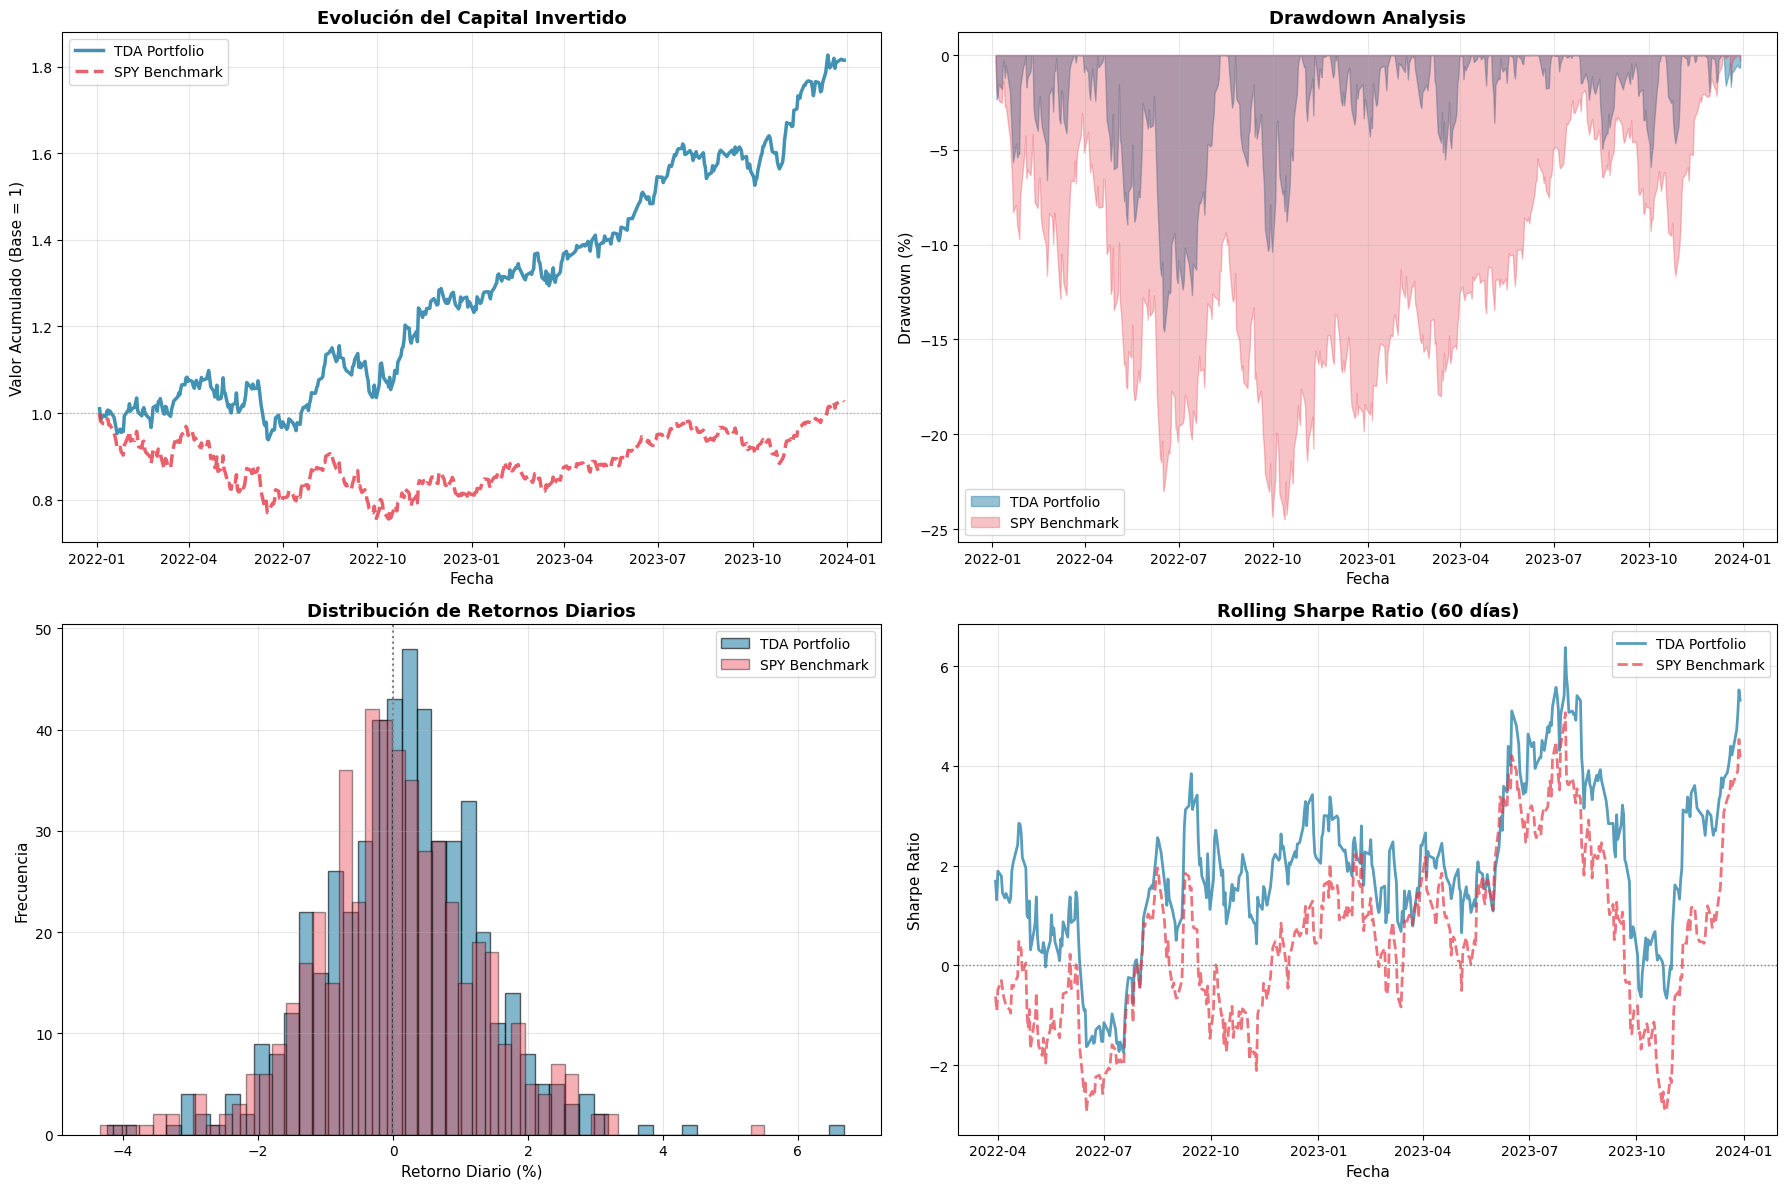

✅ Visualizaciones generadas


In [17]:
# =======================================================
# 📊 PASO 9: VISUALIZACIONES
# =======================================================

print("\n" + "="*80)
print("📊 GENERANDO VISUALIZACIONES")
print("="*80)

# Crear figura con múltiples subplots
fig = plt.figure(figsize=(18, 12))

# 1. Evolución del valor del portafolio
ax1 = plt.subplot(2, 2, 1)
ax1.plot(portfolio_cumulative.index, portfolio_cumulative.values, 
         linewidth=2.5, label='TDA Portfolio', color='#2E86AB', alpha=0.9)
ax1.plot(spy_cumulative.index, spy_cumulative.values, 
         linewidth=2.5, label='SPY Benchmark', color='#E63946', linestyle='--', alpha=0.8)
ax1.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_title('Evolución del Capital Invertido', fontsize=13, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Valor Acumulado (Base = 1)', fontsize=11)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)

# 2. Drawdown
ax2 = plt.subplot(2, 2, 2)
tda_running_max = portfolio_cumulative.cummax()
tda_drawdown = (portfolio_cumulative - tda_running_max) / tda_running_max * 100

spy_running_max = spy_cumulative.cummax()
spy_drawdown = (spy_cumulative - spy_running_max) / spy_running_max * 100

ax2.fill_between(tda_drawdown.index, tda_drawdown.values, 0, 
                  alpha=0.5, color='#2E86AB', label='TDA Portfolio')
ax2.fill_between(spy_drawdown.index, spy_drawdown.values, 0, 
                  alpha=0.3, color='#E63946', label='SPY Benchmark')
ax2.set_title('Drawdown Analysis', fontsize=13, fontweight='bold')
ax2.set_xlabel('Fecha', fontsize=11)
ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)

# 3. Distribución de retornos diarios
ax3 = plt.subplot(2, 2, 3)
ax3.hist(portfolio_daily_returns * 100, bins=50, alpha=0.6, 
         color='#2E86AB', edgecolor='black', label='TDA Portfolio')
ax3.hist(spy_returns_analysis[common_dates] * 100, bins=50, alpha=0.4, 
         color='#E63946', edgecolor='black', label='SPY Benchmark')
ax3.axvline(x=0, color='gray', linestyle=':', linewidth=1.5)
ax3.set_title('Distribución de Retornos Diarios', fontsize=13, fontweight='bold')
ax3.set_xlabel('Retorno Diario (%)', fontsize=11)
ax3.set_ylabel('Frecuencia', fontsize=11)
ax3.legend(fontsize=10, loc='best')
ax3.grid(True, alpha=0.3)

# 4. Rolling Sharpe Ratio (ventana de 60 días)
ax4 = plt.subplot(2, 2, 4)
window = 60
tda_rolling_sharpe = portfolio_daily_returns.rolling(window).mean() / portfolio_daily_returns.rolling(window).std() * np.sqrt(252)
spy_rolling_sharpe = spy_returns_analysis[common_dates].rolling(window).mean() / spy_returns_analysis[common_dates].rolling(window).std() * np.sqrt(252)

ax4.plot(tda_rolling_sharpe.index, tda_rolling_sharpe.values, 
         linewidth=2, label='TDA Portfolio', color='#2E86AB', alpha=0.8)
ax4.plot(spy_rolling_sharpe.index, spy_rolling_sharpe.values, 
         linewidth=2, label='SPY Benchmark', color='#E63946', linestyle='--', alpha=0.7)
ax4.axhline(y=0, color='gray', linestyle=':', linewidth=1)
ax4.set_title(f'Rolling Sharpe Ratio ({window} días)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Fecha', fontsize=11)
ax4.set_ylabel('Sharpe Ratio', fontsize=11)
ax4.legend(fontsize=10, loc='best')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas")
print("="*80)


⚖️  ANÁLISIS DE DISTRIBUCIÓN DE PESOS


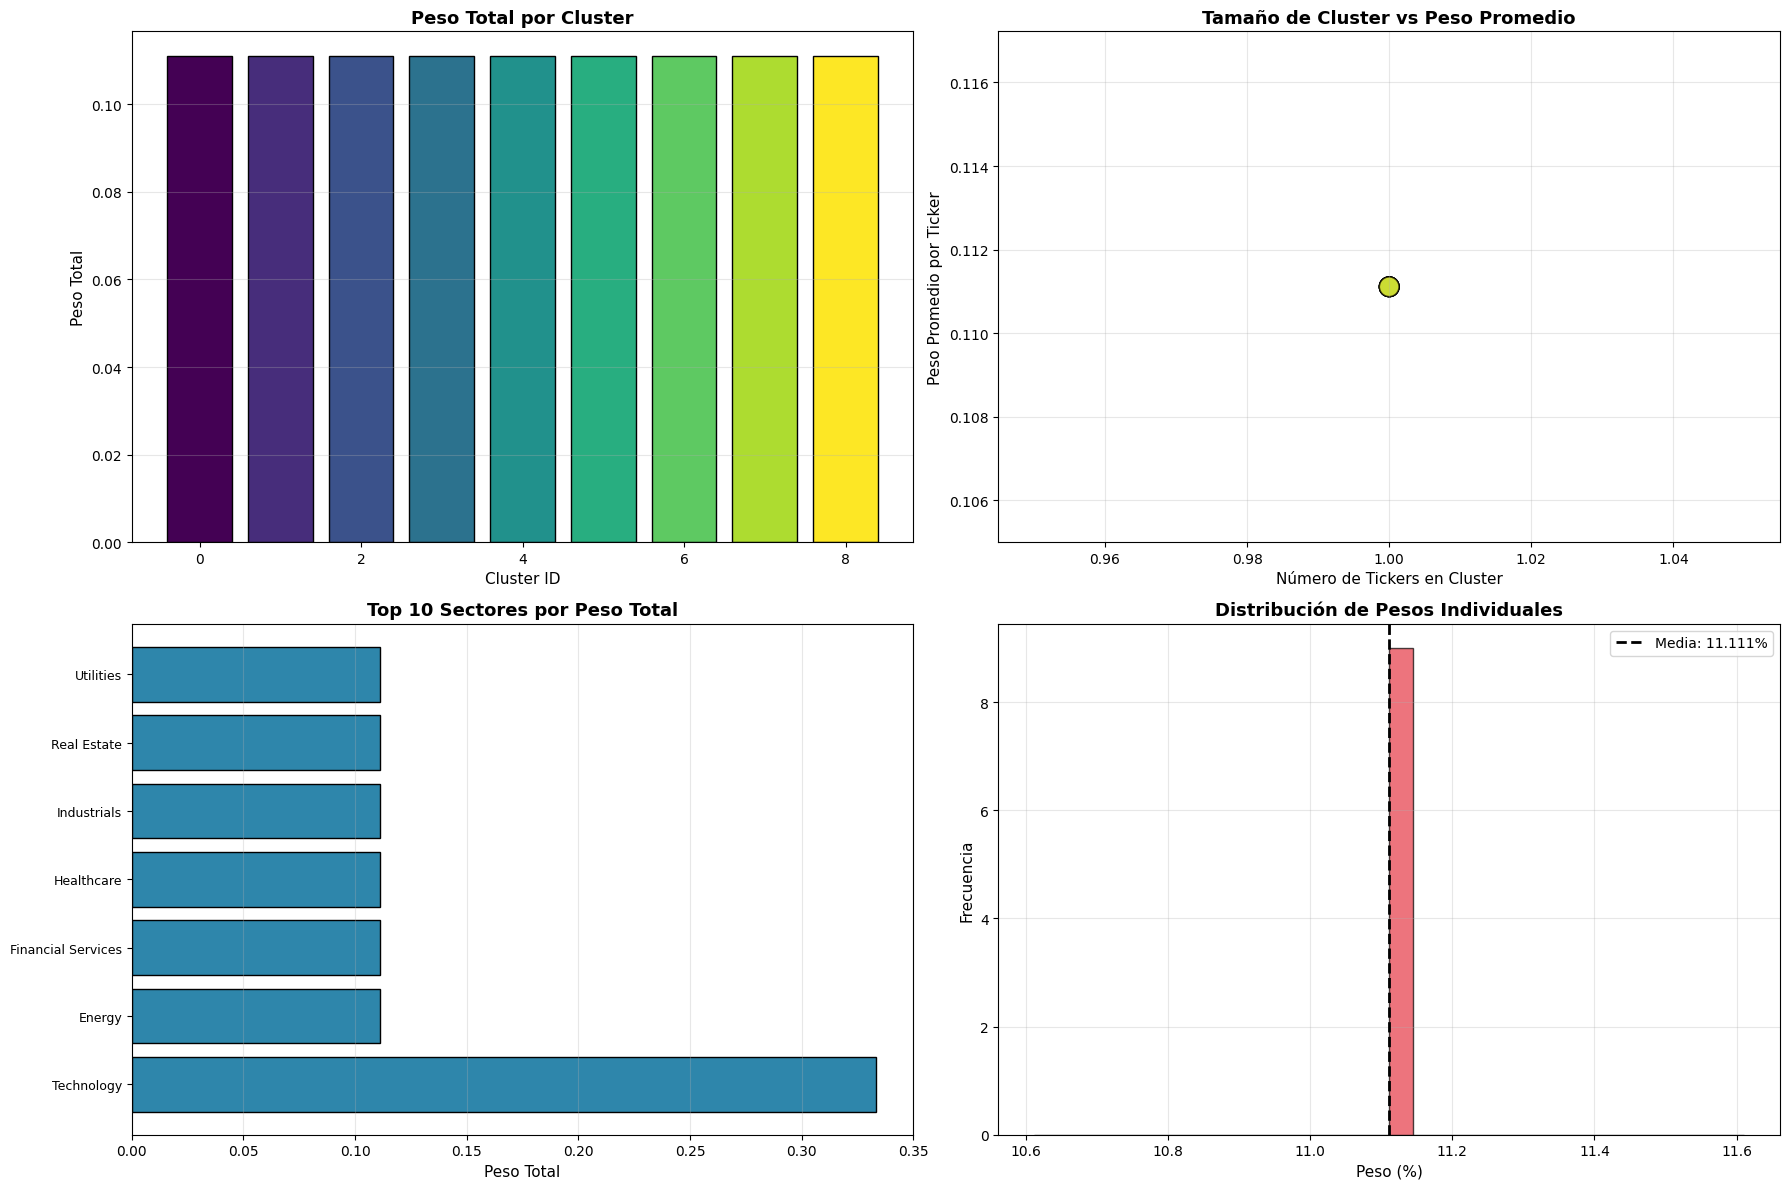


📊 EXPOSICIÓN POR SECTOR:
Technology                    :  33.33% (  3 tickers, avg=11.111%)
Energy                        :  11.11% (  1 tickers, avg=11.111%)
Financial Services            :  11.11% (  1 tickers, avg=11.111%)
Healthcare                    :  11.11% (  1 tickers, avg=11.111%)
Industrials                   :  11.11% (  1 tickers, avg=11.111%)
Real Estate                   :  11.11% (  1 tickers, avg=11.111%)
Utilities                     :  11.11% (  1 tickers, avg=11.111%)


In [18]:
# =======================================================
# 📊 PASO 10: ANÁLISIS DE DISTRIBUCIÓN DE PESOS
# =======================================================

print("\n" + "="*80)
print("⚖️  ANÁLISIS DE DISTRIBUCIÓN DE PESOS")
print("="*80)

# Crear DataFrame con información de clusters y pesos
weight_analysis = []
for ticker, weight in portfolio_weights.items():
    # Encontrar cluster del ticker
    cluster_id = [cid for cid, members in node_clusters.items() if ticker in members][0]
    cluster_size = len(node_clusters[cluster_id])
    
    weight_analysis.append({
        'ticker': ticker,
        'weight': weight,
        'cluster_id': cluster_id,
        'cluster_size': cluster_size,
        'sector': ticker_info_db.get(ticker, {}).get('sector', 'Unknown'),
        'market_cap': ticker_info_db.get(ticker, {}).get('market_cap', 0)
    })

weight_df = pd.DataFrame(weight_analysis)

# Visualización de pesos
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Distribución de pesos por cluster
ax1 = axes[0, 0]
cluster_weights = weight_df.groupby('cluster_id')['weight'].sum().sort_values(ascending=False)
colors_clusters = plt.cm.viridis(np.linspace(0, 1, len(cluster_weights)))
ax1.bar(range(len(cluster_weights)), cluster_weights.values, color=colors_clusters, edgecolor='black')
ax1.set_title('Peso Total por Cluster', fontsize=13, fontweight='bold')
ax1.set_xlabel('Cluster ID', fontsize=11)
ax1.set_ylabel('Peso Total', fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# 2. Tamaño de clusters vs peso promedio
ax2 = axes[0, 1]
cluster_analysis_viz = weight_df.groupby('cluster_id').agg({
    'weight': 'mean',
    'ticker': 'count'
}).rename(columns={'ticker': 'size'})
scatter = ax2.scatter(cluster_analysis_viz['size'], cluster_analysis_viz['weight'], 
                     s=200, alpha=0.6, c=range(len(cluster_analysis_viz)), cmap='viridis', edgecolors='black')
ax2.set_title('Tamaño de Cluster vs Peso Promedio', fontsize=13, fontweight='bold')
ax2.set_xlabel('Número de Tickers en Cluster', fontsize=11)
ax2.set_ylabel('Peso Promedio por Ticker', fontsize=11)
ax2.grid(True, alpha=0.3)

# 3. Distribución de pesos por sector
ax3 = axes[1, 0]
sector_weights = weight_df.groupby('sector')['weight'].sum().sort_values(ascending=False)[:10]
ax3.barh(range(len(sector_weights)), sector_weights.values, color='#2E86AB', edgecolor='black')
ax3.set_yticks(range(len(sector_weights)))
ax3.set_yticklabels(sector_weights.index, fontsize=9)
ax3.set_title('Top 10 Sectores por Peso Total', fontsize=13, fontweight='bold')
ax3.set_xlabel('Peso Total', fontsize=11)
ax3.grid(True, alpha=0.3, axis='x')

# 4. Histograma de pesos individuales
ax4 = axes[1, 1]
ax4.hist(weight_df['weight'] * 100, bins=30, color='#E63946', edgecolor='black', alpha=0.7)
ax4.axvline(x=weight_df['weight'].mean() * 100, color='black', linestyle='--', linewidth=2, label=f'Media: {weight_df["weight"].mean()*100:.3f}%')
ax4.set_title('Distribución de Pesos Individuales', fontsize=13, fontweight='bold')
ax4.set_xlabel('Peso (%)', fontsize=11)
ax4.set_ylabel('Frecuencia', fontsize=11)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar estadísticas por sector
print("\n📊 EXPOSICIÓN POR SECTOR:")
print("="*80)
sector_exposure = weight_df.groupby('sector').agg({
    'weight': 'sum',
    'ticker': 'count'
}).rename(columns={'ticker': 'num_tickers', 'weight': 'total_weight'})
sector_exposure['num_tickers'] = sector_exposure['num_tickers'].astype(int)
sector_exposure['avg_weight'] = sector_exposure['total_weight'] / sector_exposure['num_tickers']
sector_exposure = sector_exposure.sort_values('total_weight', ascending=False)

for sector, row in sector_exposure.head(10).iterrows():
    print(f"{sector:30s}: {row['total_weight']*100:6.2f}% ({int(row['num_tickers']):3d} tickers, avg={row['avg_weight']*100:.3f}%)")

print("="*80)

In [19]:
# =======================================================
# 📊 PASO 11: VALIDACIÓN OUT-OF-SAMPLE
# =======================================================

print("\n" + "="*80)
print("🔍 VALIDACIÓN OUT-OF-SAMPLE")
print("="*80)

# Usar los mismos pesos calculados en el período de análisis
# pero aplicarlos al período de validación
validation_tickers = [t for t in portfolio_weights.keys() if t in validation_data.columns]

print(f"📊 Configuración:")
print(f"   Tickers disponibles en validación: {len(validation_tickers)}/{len(portfolio_weights)}")
print(f"   Período: {validation_data.index[0].strftime('%Y-%m-%d')} a {validation_data.index[-1].strftime('%Y-%m-%d')}")

# Ajustar pesos para tickers disponibles (renormalizar)
adjusted_weights = {t: portfolio_weights[t] for t in validation_tickers}
total_weight = sum(adjusted_weights.values())
adjusted_weights = {t: w/total_weight for t, w in adjusted_weights.items()}

print(f"   Suma de pesos ajustados: {sum(adjusted_weights.values()):.6f}")

# Calcular retornos en validación
validation_subset = validation_data[validation_tickers].copy()
validation_returns = validation_subset.pct_change().dropna()

# Retorno del portafolio en validación
weights_array_val = np.array([adjusted_weights[ticker] for ticker in validation_returns.columns])
portfolio_val_returns = (validation_returns * weights_array_val).sum(axis=1)

# Valor acumulado
portfolio_val_cumulative = (1 + portfolio_val_returns).cumprod()

# SPY en validación
spy_val_returns = SPY_validation['SPY'].pct_change().dropna()
spy_val_cumulative = (1 + spy_val_returns).cumprod()

# Alinear fechas
common_dates_val = portfolio_val_cumulative.index.intersection(spy_val_cumulative.index)
portfolio_val_cumulative = portfolio_val_cumulative[common_dates_val]
spy_val_cumulative = spy_val_cumulative[common_dates_val]
portfolio_val_returns = portfolio_val_returns[common_dates_val]
spy_val_returns = spy_val_returns[common_dates_val]

# Calcular métricas
tda_val_metrics = calculate_portfolio_metrics(
    portfolio_val_returns, 
    portfolio_val_cumulative, 
    "TDA Portfolio (OOS)"
)

spy_val_metrics = calculate_portfolio_metrics(
    spy_val_returns, 
    spy_val_cumulative, 
    "SPY Benchmark (OOS)"
)

# Crear tabla comparativa
val_comparison = pd.DataFrame([tda_val_metrics, spy_val_metrics])
val_comparison = val_comparison.set_index('name')

print("\n📋 MÉTRICAS OUT-OF-SAMPLE:")
print("="*80)
display(val_comparison.round(4))

print("\n🎯 COMPARACIÓN ANÁLISIS vs VALIDACIÓN:")
print("="*80)
print(f"{'Métrica':<30} {'In-Sample':<15} {'Out-of-Sample':<15} {'Diferencia':<15}")
print("-"*80)
print(f"{'Retorno Anualizado (TDA):':<30} {tda_metrics['annualized_return']:>12.2f}%  {tda_val_metrics['annualized_return']:>12.2f}%  {tda_val_metrics['annualized_return'] - tda_metrics['annualized_return']:>+12.2f}%")
print(f"{'Sharpe Ratio (TDA):':<30} {tda_metrics['sharpe_ratio']:>14.4f}  {tda_val_metrics['sharpe_ratio']:>14.4f}  {tda_val_metrics['sharpe_ratio'] - tda_metrics['sharpe_ratio']:>+14.4f}")
print(f"{'Max Drawdown (TDA):':<30} {tda_metrics['max_drawdown']:>12.2f}%  {tda_val_metrics['max_drawdown']:>12.2f}%  {tda_val_metrics['max_drawdown'] - tda_metrics['max_drawdown']:>+12.2f}%")
print(f"{'Volatilidad (TDA):':<30} {tda_metrics['volatility']:>12.2f}%  {tda_val_metrics['volatility']:>12.2f}%  {tda_val_metrics['volatility'] - tda_metrics['volatility']:>+12.2f}%")

print("="*80)


🔍 VALIDACIÓN OUT-OF-SAMPLE
📊 Configuración:
   Tickers disponibles en validación: 9/9
   Período: 2024-01-02 a 2025-10-31
   Suma de pesos ajustados: 1.000000

📋 MÉTRICAS OUT-OF-SAMPLE:


,total_return,annualized_return,volatility,sharpe_ratio,max_drawdown,calmar_ratio,winning_days_pct
name,,,,,,,
TDA Portfolio (OOS),63.7367,31.0131,17.6602,1.7561,-17.7765,1.7446,56.9565
SPY Benchmark (OOS),47.4372,23.6993,16.7146,1.4179,-18.7552,1.2636,58.2609



🎯 COMPARACIÓN ANÁLISIS vs VALIDACIÓN:
Métrica                        In-Sample       Out-of-Sample   Diferencia     
--------------------------------------------------------------------------------
Retorno Anualizado (TDA):             35.05%         31.01%         -4.04%
Sharpe Ratio (TDA):                    1.8294          1.7561         -0.0733
Max Drawdown (TDA):                  -14.58%        -17.78%         -3.20%
Volatilidad (TDA):                    19.16%         17.66%         -1.50%



📊 VISUALIZACIÓN OUT-OF-SAMPLE


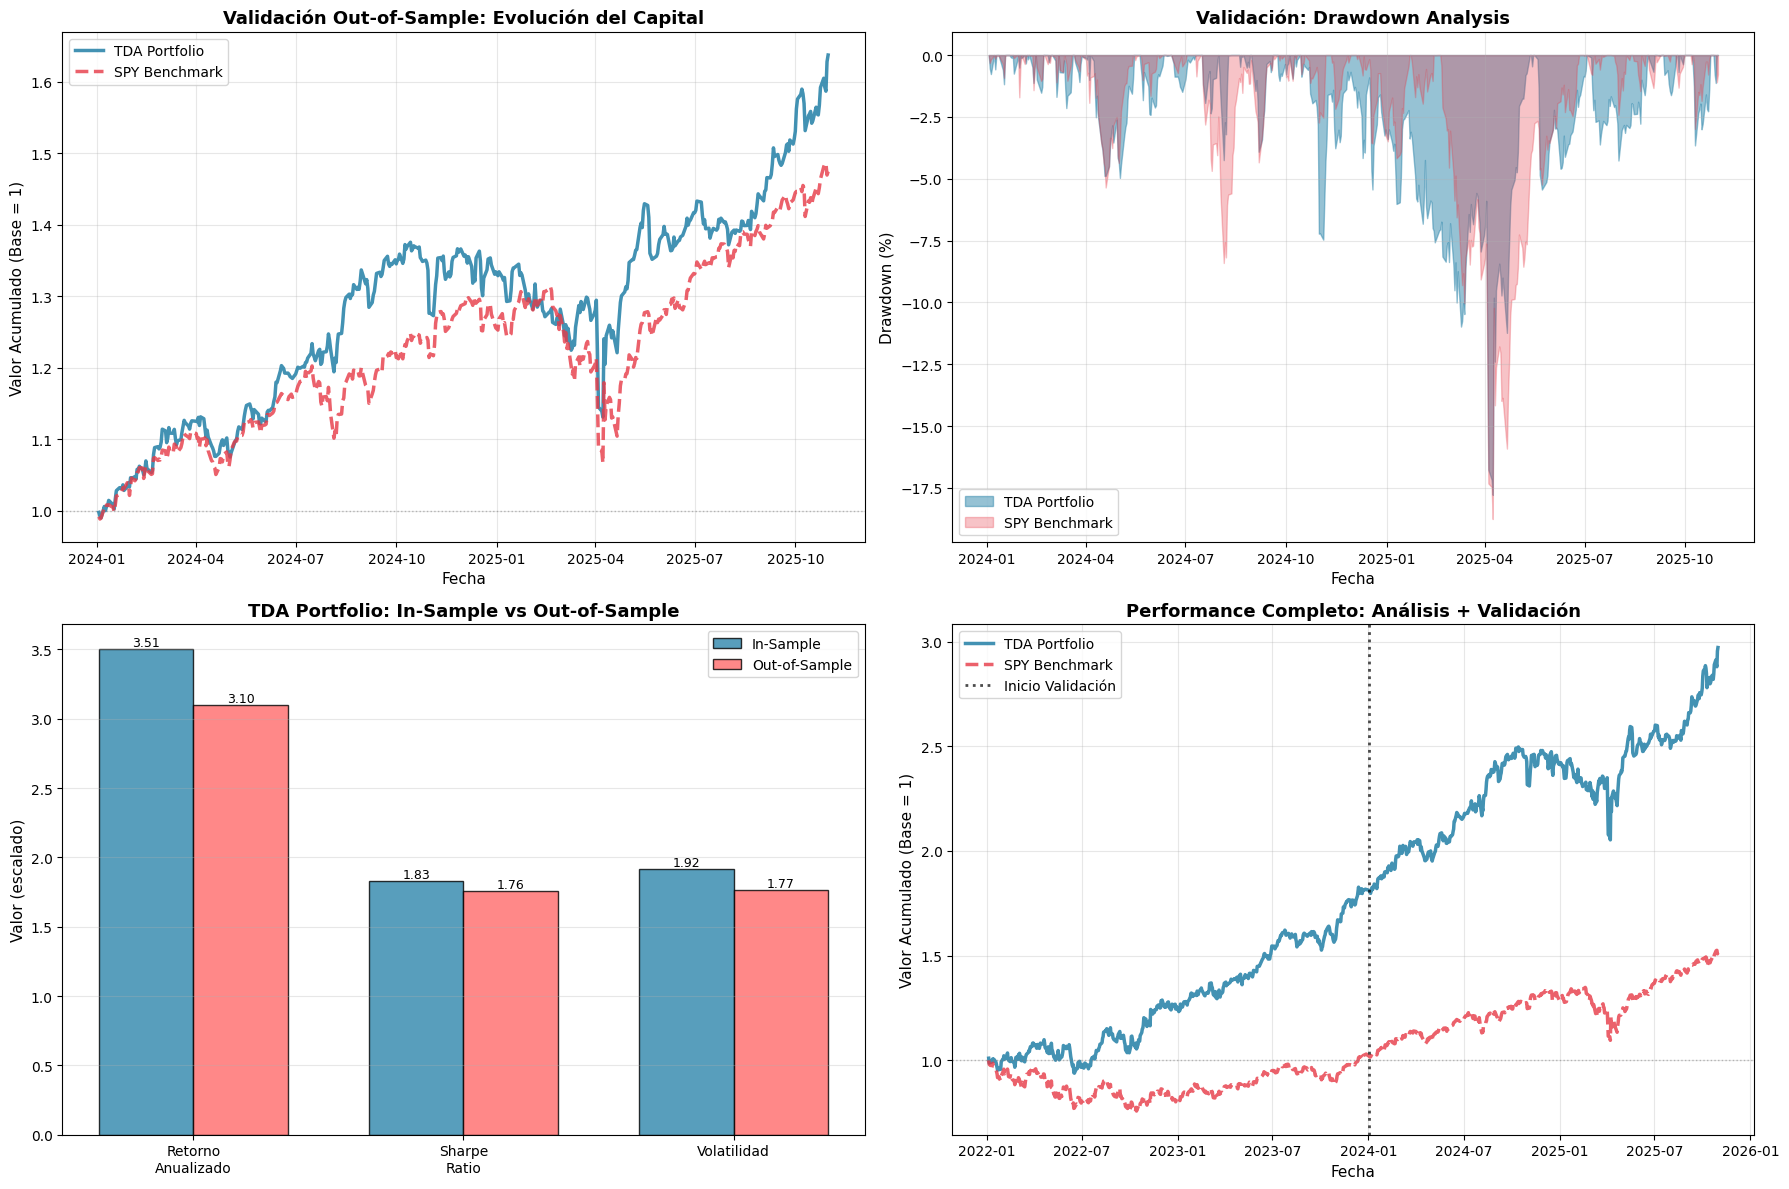

✅ Visualizaciones de validación generadas


In [20]:
# =======================================================
# 📊 PASO 12: VISUALIZACIÓN DE VALIDACIÓN
# =======================================================

print("\n" + "="*80)
print("📊 VISUALIZACIÓN OUT-OF-SAMPLE")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Evolución en validación
ax1 = axes[0, 0]
ax1.plot(portfolio_val_cumulative.index, portfolio_val_cumulative.values, 
         linewidth=2.5, label='TDA Portfolio', color='#2E86AB', alpha=0.9)
ax1.plot(spy_val_cumulative.index, spy_val_cumulative.values, 
         linewidth=2.5, label='SPY Benchmark', color='#E63946', linestyle='--', alpha=0.8)
ax1.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_title('Validación Out-of-Sample: Evolución del Capital', fontsize=13, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Valor Acumulado (Base = 1)', fontsize=11)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)

# 2. Drawdown en validación
ax2 = axes[0, 1]
tda_val_running_max = portfolio_val_cumulative.cummax()
tda_val_drawdown = (portfolio_val_cumulative - tda_val_running_max) / tda_val_running_max * 100

spy_val_running_max = spy_val_cumulative.cummax()
spy_val_drawdown = (spy_val_cumulative - spy_val_running_max) / spy_val_running_max * 100

ax2.fill_between(tda_val_drawdown.index, tda_val_drawdown.values, 0, 
                  alpha=0.5, color='#2E86AB', label='TDA Portfolio')
ax2.fill_between(spy_val_drawdown.index, spy_val_drawdown.values, 0, 
                  alpha=0.3, color='#E63946', label='SPY Benchmark')
ax2.set_title('Validación: Drawdown Analysis', fontsize=13, fontweight='bold')
ax2.set_xlabel('Fecha', fontsize=11)
ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)

# 3. Comparación In-Sample vs Out-of-Sample (TDA)
ax3 = axes[1, 0]
metrics_names = ['Retorno\nAnualizado', 'Sharpe\nRatio', 'Volatilidad']
is_values = [tda_metrics['annualized_return']/10, tda_metrics['sharpe_ratio'], tda_metrics['volatility']/10]
oos_values = [tda_val_metrics['annualized_return']/10, tda_val_metrics['sharpe_ratio'], tda_val_metrics['volatility']/10]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax3.bar(x - width/2, is_values, width, label='In-Sample', color='#2E86AB', alpha=0.8, edgecolor='black')
bars2 = ax3.bar(x + width/2, oos_values, width, label='Out-of-Sample', color='#FF6B6B', alpha=0.8, edgecolor='black')

ax3.set_ylabel('Valor (escalado)', fontsize=11)
ax3.set_title('TDA Portfolio: In-Sample vs Out-of-Sample', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(metrics_names, fontsize=10)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# 4. Retornos acumulados completos (análisis + validación)
ax4 = axes[1, 1]

# Concatenar períodos
portfolio_full = pd.concat([portfolio_cumulative, portfolio_val_cumulative * portfolio_cumulative.iloc[-1]])
spy_full = pd.concat([spy_cumulative, spy_val_cumulative * spy_cumulative.iloc[-1]])

ax4.plot(portfolio_full.index, portfolio_full.values, 
         linewidth=2.5, label='TDA Portfolio', color='#2E86AB', alpha=0.9)
ax4.plot(spy_full.index, spy_full.values, 
         linewidth=2.5, label='SPY Benchmark', color='#E63946', linestyle='--', alpha=0.8)

# Marcar separación entre períodos
sep_date = validation_data.index[0]
ax4.axvline(x=sep_date, color='black', linestyle=':', linewidth=2, alpha=0.7, label='Inicio Validación')
ax4.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)

ax4.set_title('Performance Completo: Análisis + Validación', fontsize=13, fontweight='bold')
ax4.set_xlabel('Fecha', fontsize=11)
ax4.set_ylabel('Valor Acumulado (Base = 1)', fontsize=11)
ax4.legend(fontsize=10, loc='best')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizaciones de validación generadas")
print("="*80)

# 📊 Resumen de la Estrategia TDA

 ✅ Implementación Completada

**Objetivo:** Replicar la estrategia de construcción de portafolio usando Topological Data Analysis (TDA) del artículo "Portfolio Construction Using Topological Data Analysis"

🔧 Pasos Implementados

1. **Selección de Universo** - Top 200 componentes del S&P 500 por market cap
2. **Cálculo de Log-Returns** - Transformación logarítmica de los retornos
3. **Reducción de Dimensionalidad** - PCA (80% varianza) + UMAP (1D)
4. **Clustering Topológico** - DBSCAN con métrica de correlación
5. **Construcción de Grafo** - KeplerMapper para estructura topológica
6. **Asignación de Pesos** - Equal weighting por cluster
7. **Backtesting** - Período in-sample (análisis)
8. **Validación** - Período out-of-sample
9. **Métricas de Performance** - Sharpe, Drawdown, Beta, Alpha
10. **Visualizaciones** - Gráficos comparativos vs SPY

 📈 Características Clave

- **Lookback Window:** Período completo de análisis (2015-2024)
- **Universo:** Top 200 tickers por capitalización de mercado
- **Benchmark:** SPY (S&P 500 ETF)
- **Estrategia de Pesos:** Igual peso por cluster, distribuido equitativamente entre tickers
- **Validación:** Out-of-sample desde 2024-01-01

 🎯 Próximos Pasos Opcionales

- Implementar **rebalanceo periódico** (cada 125 días según el artículo)
- Agregar análisis de **sensibilidad** a parámetros de DBSCAN
- Comparar con benchmark de **Top 200 equal-weighted**
- Implementar **rolling window backtest** para múltiples períodos

# Analisis portafolio generado

In [21]:
# =======================================================
# 📊 ANÁLISIS DETALLADO DEL PORTAFOLIO GENERADO
# =======================================================

print("="*80)
print("📊 ANÁLISIS COMPLETO DEL PORTAFOLIO TDA")
print("="*80)

# Crear análisis detallado por ticker
portfolio_analysis = []

for ticker in portfolio_weights.keys():
    # Información básica
    info = ticker_info_db.get(ticker, {})
    metrics = financial_metrics_dict.get(ticker, {})
    
    # Buscar cluster
    ticker_cluster = None
    for cid, members in node_clusters.items():
        if ticker in members:
            ticker_cluster = cid
            break
    
    # Performance en período de análisis
    ticker_prices = tickers_data[ticker]
    ticker_returns = ticker_prices.pct_change().dropna()
    
    # Calcular métricas individuales
    total_return = (ticker_prices.iloc[-1] / ticker_prices.iloc[0] - 1) * 100
    volatility = ticker_returns.std() * np.sqrt(252) * 100
    sharpe = metrics.get('sharpe_ratio', 0)
    
    portfolio_analysis.append({
        'Ticker': ticker,
        'Peso (%)': portfolio_weights[ticker] * 100,
        'Cluster': str(ticker_cluster),
        'Sector': info.get('sector', 'Unknown'),
        'Market Cap ($B)': info.get('market_cap', 0) / 1e9,
        'Retorno Total (%)': total_return,
        'Volatilidad (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': metrics.get('max_drawdown', 0) * 100,
        'Beta': info.get('beta', np.nan)
    })

# Crear DataFrame
portfolio_df = pd.DataFrame(portfolio_analysis)
portfolio_df = portfolio_df.sort_values('Peso (%)', ascending=False)

print(f"\n📋 COMPOSICIÓN DEL PORTAFOLIO ({len(portfolio_df)} tickers):")
print("="*80)
display(portfolio_df.round(4))

print(f"\n📊 ESTADÍSTICAS AGREGADAS DEL PORTAFOLIO:")
print("="*80)
print(f"{'Peso promedio por ticker:':<35} {portfolio_df['Peso (%)'].mean():.4f}%")
print(f"{'Peso máximo:':<35} {portfolio_df['Peso (%)'].max():.4f}%")
print(f"{'Peso mínimo:':<35} {portfolio_df['Peso (%)'].min():.4f}%")
print(f"{'Desv. estándar de pesos:':<35} {portfolio_df['Peso (%)'].std():.4f}%")
print(f"\n{'Retorno promedio (ponderado):':<35} {(portfolio_df['Retorno Total (%)'] * portfolio_df['Peso (%)'] / 100).sum():.2f}%")
print(f"{'Volatilidad promedio (ponderado):':<35} {(portfolio_df['Volatilidad (%)'] * portfolio_df['Peso (%)'] / 100).sum():.2f}%")
print(f"{'Sharpe promedio (ponderado):':<35} {(portfolio_df['Sharpe Ratio'] * portfolio_df['Peso (%)'] / 100).sum():.4f}")
print(f"\n{'Market Cap promedio:':<35} ${portfolio_df['Market Cap ($B)'].mean():.2f}B")
print(f"{'Market Cap total del portafolio:':<35} ${portfolio_df['Market Cap ($B)'].sum():.2f}B")

print(f"\n📊 DISTRIBUCIÓN POR SECTORES:")
print("="*80)
sector_stats = portfolio_df.groupby('Sector').agg({
    'Peso (%)': 'sum',
    'Ticker': 'count',
    'Retorno Total (%)': 'mean',
    'Volatilidad (%)': 'mean'
}).rename(columns={'Ticker': 'Num Tickers'})
sector_stats = sector_stats.sort_values('Peso (%)', ascending=False)

for sector, row in sector_stats.iterrows():
    print(f"{sector:30s}: {row['Peso (%)']:6.2f}% ({int(row['Num Tickers']):2d} tickers) | "
          f"Ret Avg: {row['Retorno Total (%)']:6.2f}% | Vol Avg: {row['Volatilidad (%)']:5.2f}%")

print(f"\n📊 DISTRIBUCIÓN POR CLUSTERS:")
print("="*80)
cluster_stats = portfolio_df.groupby('Cluster').agg({
    'Peso (%)': 'sum',
    'Ticker': 'count'
}).rename(columns={'Ticker': 'Num Tickers'})
cluster_stats = cluster_stats.sort_values('Peso (%)', ascending=False)

for cluster, row in cluster_stats.iterrows():
    print(f"Cluster {cluster:>10s}: {row['Peso (%)']:6.2f}% ({int(row['Num Tickers']):2d} tickers)")

print("="*80)

📊 ANÁLISIS COMPLETO DEL PORTAFOLIO TDA

📋 COMPOSICIÓN DEL PORTAFOLIO (9 tickers):


,Ticker,Peso (%),Cluster,Sector,Market Cap ($B),Retorno Total (%),Volatilidad (%),Sharpe Ratio,Max Drawdown (%),Beta
0,IRM,11.1111,cube0_cluster0,Real Estate,19.3766,49.2951,29.4328,0.8335,-22.6272,NaN
1,AVGO,11.1111,cube1_cluster0,Technology,51.1978,77.6477,34.9162,1.0026,-34.8375,NaN
2,ACGL,11.1111,cube2_cluster0,Financial Services,26.3546,66.7116,26.7496,1.0967,-18.4222,NaN
3,AAPL,11.1111,cube3_cluster0,Technology,2966.3664,6.9885,29.0756,0.2619,-30.9128,NaN
4,FICO,11.1111,cube4_cluster0,Technology,28.7669,162.6791,40.3081,1.3989,-34.7687,NaN
5,HII,11.1111,cube6_cluster0,Industrials,9.9108,46.0261,24.3356,0.9054,-24.2822,NaN
6,CAH,11.1111,cube6_cluster1,Healthcare,24.1463,104.6303,24.3116,1.6064,-20.9521,NaN
7,PCG,11.1111,cube8_cluster0,Utilities,45.5006,47.7483,29.1456,0.8210,-24.9424,NaN
8,MPC,11.1111,cube9_cluster0,Energy,54.0078,137.2760,33.4097,1.4715,-30.2156,NaN



📊 ESTADÍSTICAS AGREGADAS DEL PORTAFOLIO:
Peso promedio por ticker:           11.1111%
Peso máximo:                        11.1111%
Peso mínimo:                        11.1111%
Desv. estándar de pesos:            0.0000%

Retorno promedio (ponderado):       77.67%
Volatilidad promedio (ponderado):   30.19%
Sharpe promedio (ponderado):        1.0442

Market Cap promedio:                $358.40B
Market Cap total del portafolio:    $3225.63B

📊 DISTRIBUCIÓN POR SECTORES:
Technology                    :  33.33% ( 3 tickers) | Ret Avg:  82.44% | Vol Avg: 34.77%
Energy                        :  11.11% ( 1 tickers) | Ret Avg: 137.28% | Vol Avg: 33.41%
Financial Services            :  11.11% ( 1 tickers) | Ret Avg:  66.71% | Vol Avg: 26.75%
Healthcare                    :  11.11% ( 1 tickers) | Ret Avg: 104.63% | Vol Avg: 24.31%
Industrials                   :  11.11% ( 1 tickers) | Ret Avg:  46.03% | Vol Avg: 24.34%
Real Estate                   :  11.11% ( 1 tickers) | Ret Avg:  49.30% | Vol

## Entrenamiento

### Grafica mostrando las distribuciones y comportamiento portafolio etapa de entrenamiento


📊 VISUALIZACIÓN COMPLETA DEL PERÍODO DE ANÁLISIS

📋 Información:
   Período: 2022-01-03 a 2023-12-29
   Tickers en portafolio: 9
   Días de trading: 501

📊 Panel 1: Evolución Normalizada
📊 Panel 2: Contribución Ponderada

💰 Simulación de inversión:
   Si inviertes $1.00 total en el portafolio al inicio del análisis:
   • IRM  : $0.1111 → $0.1659 (+49.30%)
   • AVGO : $0.1111 → $0.1974 (+77.65%)
   • ACGL : $0.1111 → $0.1852 (+66.71%)
   • AAPL : $0.1111 → $0.1189 (+6.99%)
   • FICO : $0.1111 → $0.2919 (+162.68%)
   • HII  : $0.1111 → $0.1623 (+46.03%)
   • CAH  : $0.1111 → $0.2274 (+104.63%)
   • PCG  : $0.1111 → $0.1642 (+47.75%)
   • MPC  : $0.1111 → $0.2636 (+137.28%)


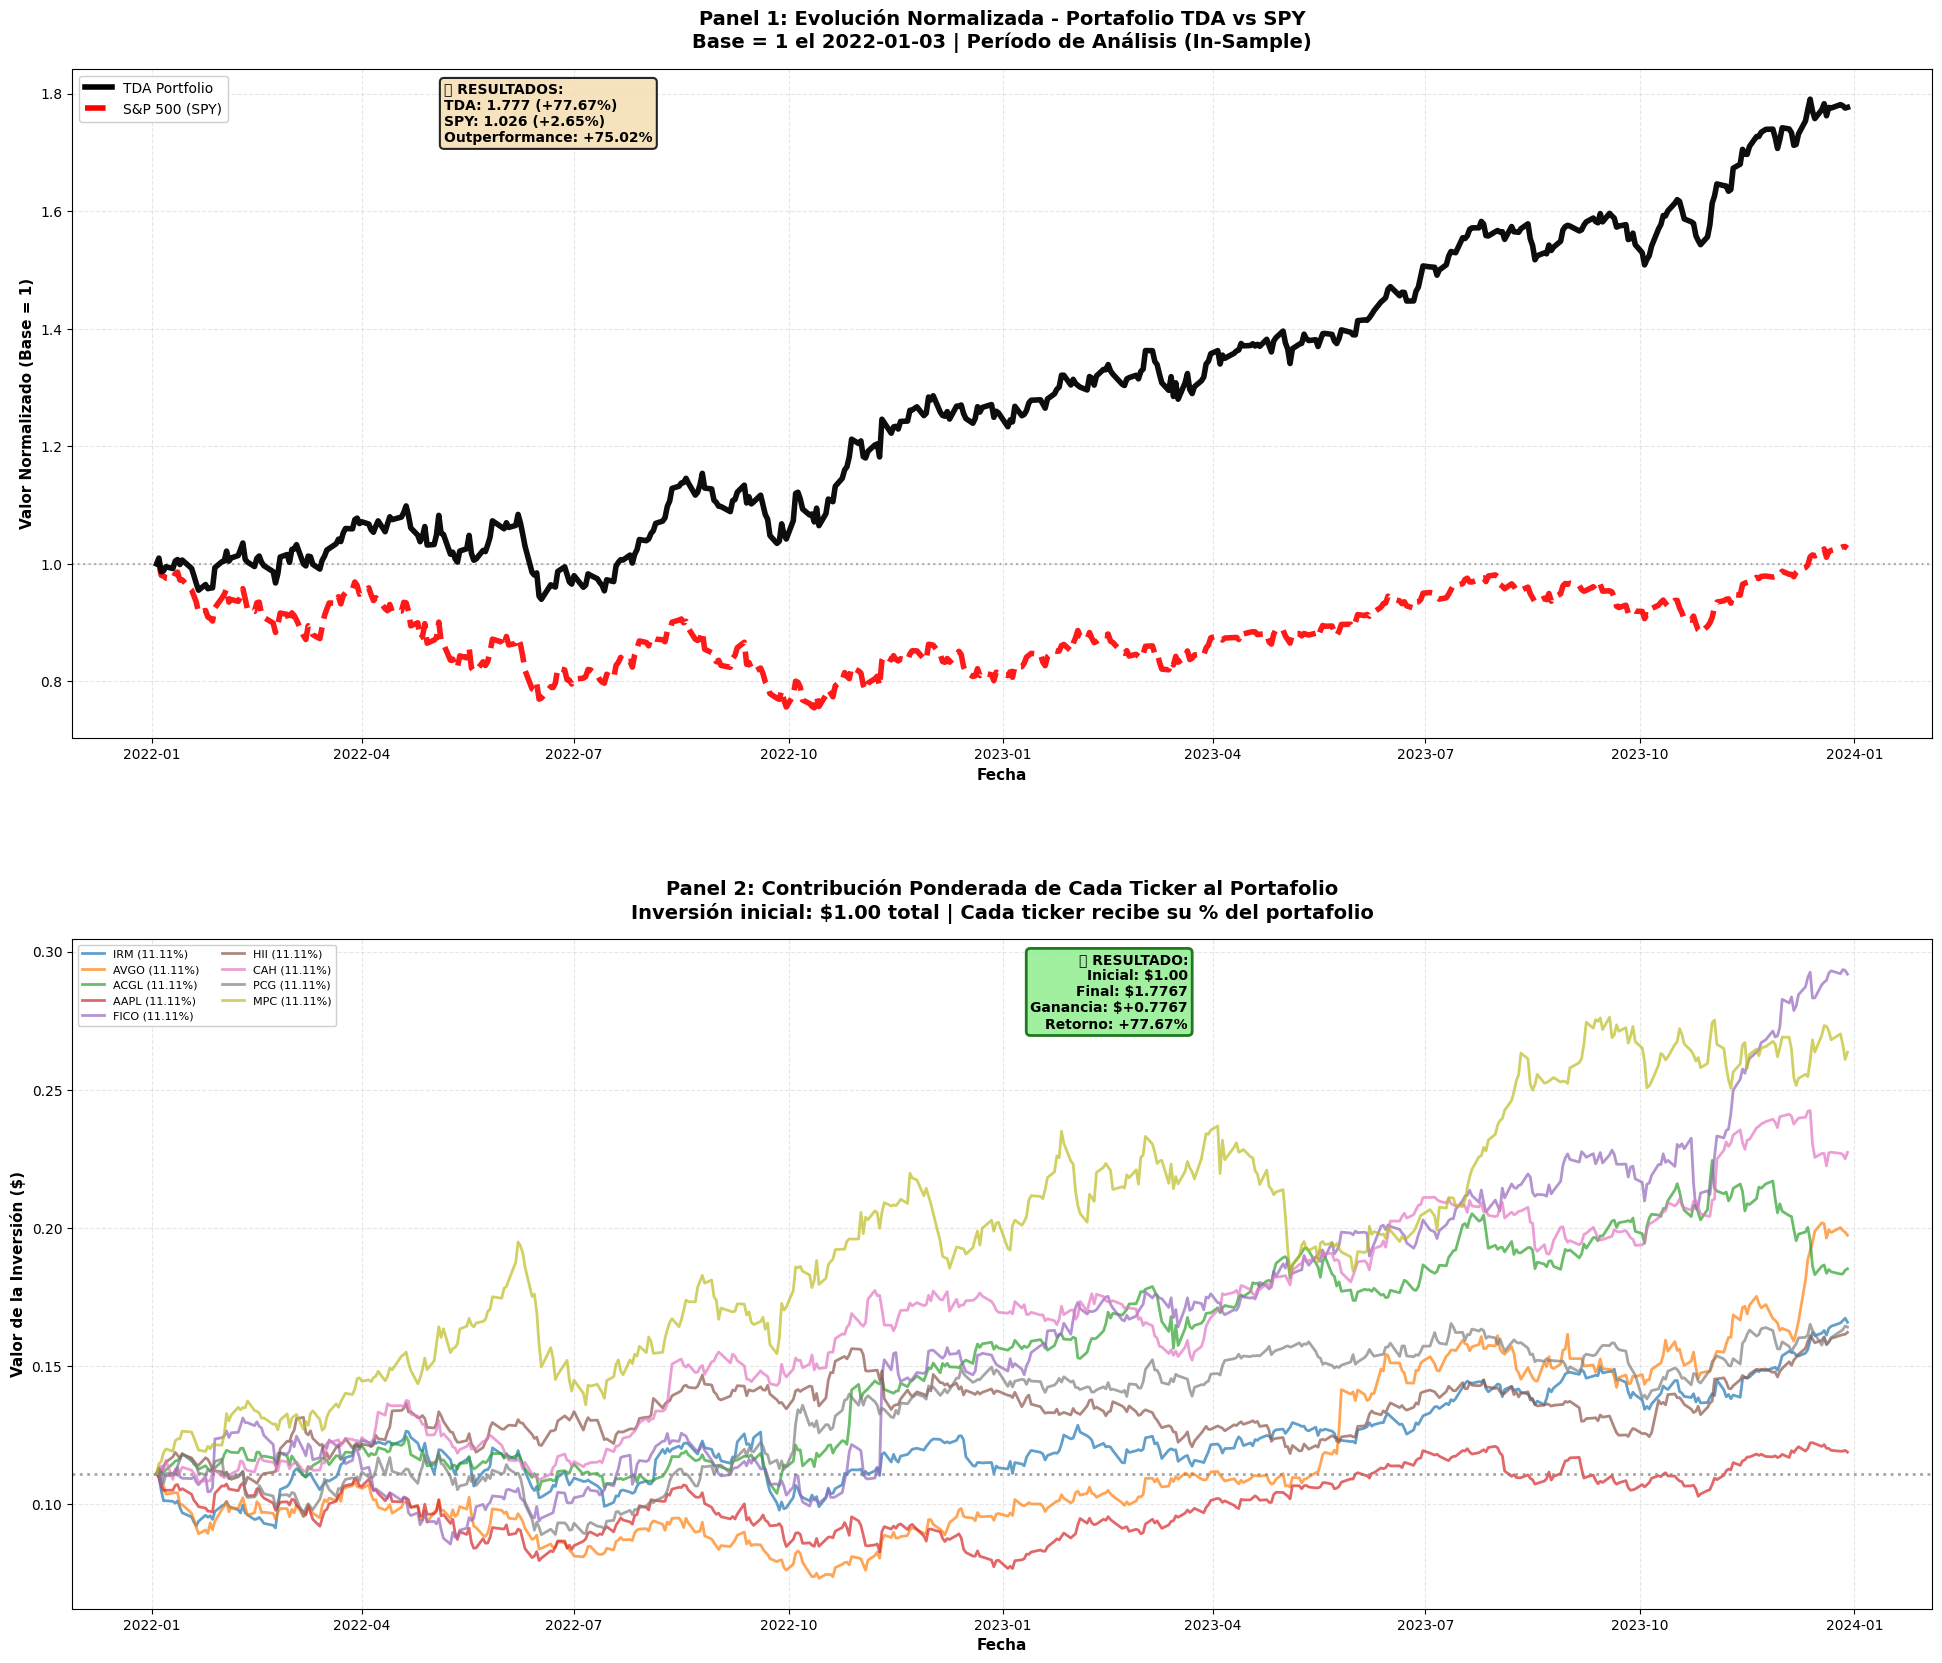


📊 RESUMEN CONSOLIDADO DEL ANÁLISIS:
   Período: 2022-01-03 a 2023-12-29
   Días de trading: 501
   Tickers en portafolio: 9

   💰 INVERSIÓN:
      Inicial: $1.00
      Final: $1.7767
      Ganancia: $+0.7767
      Retorno: +77.67%

   📈 vs SPY:
      TDA Portfolio: +77.67%
      S&P 500 (SPY): +2.65%
      Outperformance: +75.02%

✅ Visualización completa del período de análisis generada


In [22]:
# =======================================================
# 📊 GRÁFICAS CONSOLIDADAS DEL PERÍODO DE ANÁLISIS (IN-SAMPLE)
# =======================================================

print("\n" + "="*80)
print("📊 VISUALIZACIÓN COMPLETA DEL PERÍODO DE ANÁLISIS")
print("="*80)

# Preparar datos de análisis
analysis_tickers = list(portfolio_weights.keys())
analysis_prices = tickers_data[analysis_tickers].copy()
spy_analysis_prices = SPY_analysis['SPY'].copy()

print(f"\n📋 Información:")
print(f"   Período: {analysis_prices.index[0].strftime('%Y-%m-%d')} a {analysis_prices.index[-1].strftime('%Y-%m-%d')}")
print(f"   Tickers en portafolio: {len(analysis_tickers)}")
print(f"   Días de trading: {len(analysis_prices)}")

# =======================================================================
# CREAR FIGURA CON 2 PANELES
# =======================================================================
fig = plt.figure(figsize=(24, 20))
gs = fig.add_gridspec(2, 1, hspace=0.3)

# =======================================================================
# PANEL 1: PORTAFOLIO vs SPY (BASE = 1)
# =======================================================================
ax1 = fig.add_subplot(gs[0, 0])

print(f"\n📊 Panel 1: Evolución Normalizada")

# Calcular portafolio TDA normalizado
weights_array = np.array([portfolio_weights[t] for t in analysis_tickers])
analysis_normalized = analysis_prices / analysis_prices.iloc[0]
portfolio_analysis_normalized = (analysis_normalized.values * weights_array).sum(axis=1)

# Graficar portafolio TDA
ax1.plot(analysis_prices.index, portfolio_analysis_normalized, 
        linewidth=4, color='black', label='TDA Portfolio', alpha=0.95, zorder=100)

# Graficar SPY normalizado
spy_normalized_analysis = spy_analysis_prices / spy_analysis_prices.iloc[0]
ax1.plot(spy_analysis_prices.index, spy_normalized_analysis, 
        linewidth=4, color='red', linestyle='--', label='S&P 500 (SPY)', alpha=0.9, zorder=99)

# Configuración Panel 1
ax1.axhline(y=1.0, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
ax1.set_title('Panel 1: Evolución Normalizada - Portafolio TDA vs SPY\n' +
             f'Base = 1 el {analysis_prices.index[0].strftime("%Y-%m-%d")} | Período de Análisis (In-Sample)', 
             fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Fecha', fontsize=11, fontweight='bold')
ax1.set_ylabel('Valor Normalizado (Base = 1)', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Leyenda Panel 1
handles = [
    plt.Line2D([0], [0], color='black', linewidth=4, label='TDA Portfolio'),
    plt.Line2D([0], [0], color='red', linewidth=4, linestyle='--', label='S&P 500 (SPY)')
]
ax1.legend(handles=handles, fontsize=10, loc='upper left', framealpha=0.95)

# Métricas Panel 1
final_portfolio_analysis = portfolio_analysis_normalized[-1]
final_spy_analysis = spy_normalized_analysis.iloc[-1]
ret_portfolio_analysis = (final_portfolio_analysis - 1) * 100
ret_spy_analysis = (final_spy_analysis - 1) * 100
outperformance_analysis = ret_portfolio_analysis - ret_spy_analysis

textstr = f'📊 RESULTADOS:\n'
textstr += f'TDA: {final_portfolio_analysis:.3f} ({ret_portfolio_analysis:+.2f}%)\n'
textstr += f'SPY: {final_spy_analysis:.3f} ({ret_spy_analysis:+.2f}%)\n'
textstr += f'Outperformance: {outperformance_analysis:+.2f}%'

ax1.text(0.2, 0.98, textstr, transform=ax1.transAxes, fontsize=10,
       verticalalignment='top', fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85, edgecolor='black', linewidth=1.5))

# =======================================================================
# PANEL 2: TICKERS PONDERADOS - CONTRIBUCIÓN AL PORTAFOLIO
# =======================================================================
ax2 = fig.add_subplot(gs[1, 0])

print(f"📊 Panel 2: Contribución Ponderada")
print(f"\n💰 Simulación de inversión:")
print(f"   Si inviertes $1.00 total en el portafolio al inicio del análisis:")

# Calcular contribución de cada ticker (normalizado × peso)
portfolio_contributions_analysis = {}
for ticker in analysis_tickers:
    ticker_normalized = analysis_prices[ticker] / analysis_prices[ticker].iloc[0]
    ticker_weight = portfolio_weights[ticker]
    contribution = ticker_normalized * ticker_weight
    portfolio_contributions_analysis[ticker] = contribution
    
    # Graficar
    ax2.plot(analysis_prices.index, contribution, 
            alpha=0.7, linewidth=2,
            label=f'{ticker} ({ticker_weight*100:.2f}%)')
    
    # Imprimir resumen
    valor_inicial = ticker_weight
    valor_final = contribution.iloc[-1]
    ret_pct = (valor_final / valor_inicial - 1) * 100
    print(f"   • {ticker:5s}: ${valor_inicial:.4f} → ${valor_final:.4f} ({ret_pct:+.2f}%)")

# Portafolio total
portfolio_total_analysis = sum(portfolio_contributions_analysis.values())

# Línea de referencia
ax2.axhline(y=1.0/len(analysis_tickers), color='gray', linestyle=':', linewidth=2, alpha=0.7)

# Configuración Panel 2
ax2.set_title('Panel 2: Contribución Ponderada de Cada Ticker al Portafolio\n' +
             'Inversión inicial: $1.00 total | Cada ticker recibe su % del portafolio',
             fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Fecha', fontsize=11, fontweight='bold')
ax2.set_ylabel('Valor de la Inversión ($)', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')

# Leyenda Panel 2
if len(analysis_tickers) <= 12:
    ax2.legend(fontsize=8, loc='upper left', ncol=2, framealpha=0.95)
else:
    handles = [
        plt.Line2D([0], [0], color='gray', linewidth=2, linestyle=':', 
                  label=f'{len(analysis_tickers)} Tickers (ponderados)')
    ]
    ax2.legend(handles=handles, fontsize=10, loc='upper left', framealpha=0.95)

# Métricas Panel 2
valor_final_total_analysis = portfolio_total_analysis.iloc[-1]
ganancia_total_analysis = valor_final_total_analysis - 1.0
ret_total_analysis = (valor_final_total_analysis - 1.0) * 100

textstr2 = f'💰 RESULTADO:\n'
textstr2 += f'Inicial: $1.00\n'
textstr2 += f'Final: ${valor_final_total_analysis:.4f}\n'
textstr2 += f'Ganancia: ${ganancia_total_analysis:+.4f}\n'
textstr2 += f'Retorno: {ret_total_analysis:+.2f}%'

ax2.text(0.6, 0.98, textstr2, transform=ax2.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.85, 
                 edgecolor='darkgreen', linewidth=2))


plt.tight_layout()
plt.show()

# Resumen final consolidado
print(f"\n" + "="*80)
print(f"📊 RESUMEN CONSOLIDADO DEL ANÁLISIS:")
print(f"="*80)
print(f"   Período: {analysis_prices.index[0].strftime('%Y-%m-%d')} a {analysis_prices.index[-1].strftime('%Y-%m-%d')}")
print(f"   Días de trading: {len(analysis_prices)}")
print(f"   Tickers en portafolio: {len(analysis_tickers)}")
print(f"\n   💰 INVERSIÓN:")
print(f"      Inicial: $1.00")
print(f"      Final: ${valor_final_total_analysis:.4f}")
print(f"      Ganancia: ${ganancia_total_analysis:+.4f}")
print(f"      Retorno: {ret_total_analysis:+.2f}%")
print(f"\n   📈 vs SPY:")
print(f"      TDA Portfolio: {ret_portfolio_analysis:+.2f}%")
print(f"      S&P 500 (SPY): {ret_spy_analysis:+.2f}%")
print(f"      Outperformance: {outperformance_analysis:+.2f}%")
print(f"\n✅ Visualización completa del período de análisis generada")
print("="*80)



### Resumen visual


📊 ANÁLISIS VISUAL: TODOS LOS TICKERS (9 total)


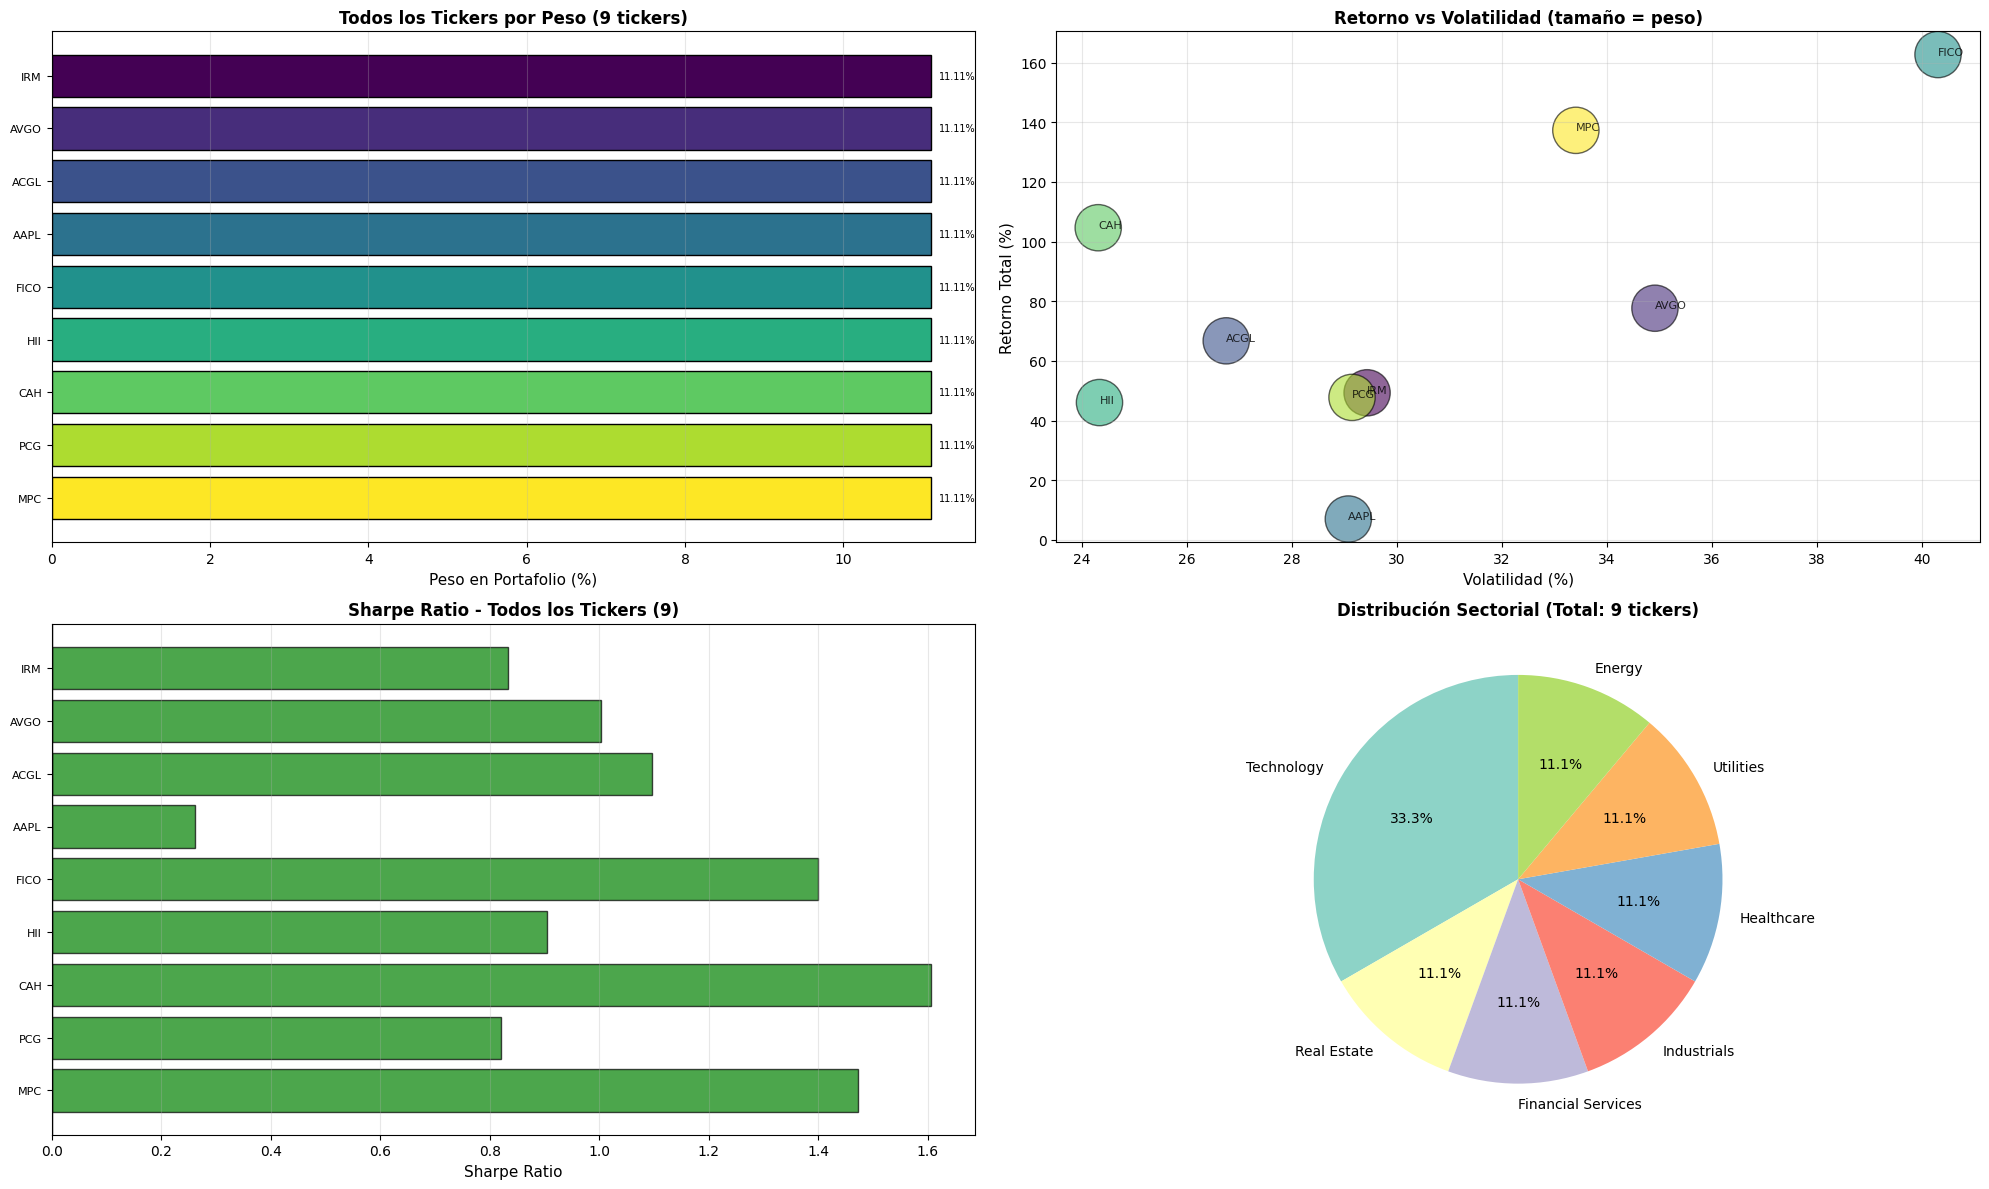

✅ Análisis visual completado para 9 tickers


In [23]:
# =======================================================
# 📊 RESUMEN VISUAL: TODOS LOS TICKERS DEL PORTAFOLIO
# =======================================================

print("\n" + "="*80)
print(f"📊 ANÁLISIS VISUAL: TODOS LOS TICKERS ({len(portfolio_df)} total)")
print("="*80)

# Usar TODOS los tickers del portafolio
all_tickers = portfolio_df.copy()

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# 1. Pesos de TODOS los tickers
ax1 = axes[0, 0]
colors = plt.cm.viridis(np.linspace(0, 1, len(all_tickers)))
bars = ax1.barh(range(len(all_tickers)), all_tickers['Peso (%)'], color=colors, edgecolor='black')
ax1.set_yticks(range(len(all_tickers)))
ax1.set_yticklabels(all_tickers['Ticker'], fontsize=8)
ax1.set_xlabel('Peso en Portafolio (%)', fontsize=11)
ax1.set_title(f'Todos los Tickers por Peso ({len(all_tickers)} tickers)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
ax1.invert_yaxis()

# Añadir valores solo si no son demasiados tickers
if len(all_tickers) <= 30:
    for i, (idx, row) in enumerate(all_tickers.iterrows()):
        ax1.text(row['Peso (%)'] + 0.1, i, f"{row['Peso (%)']:.2f}%", 
                 va='center', fontsize=7)

# 2. Retorno vs Volatilidad (TODOS)
ax2 = axes[0, 1]
scatter = ax2.scatter(all_tickers['Volatilidad (%)'], all_tickers['Retorno Total (%)'], 
                      s=all_tickers['Peso (%)'] * 100, alpha=0.6, 
                      c=range(len(all_tickers)), cmap='viridis', edgecolors='black')

# Anotar solo si no son demasiados tickers
if len(all_tickers) <= 20:
    for idx, row in all_tickers.iterrows():
        ax2.annotate(row['Ticker'], 
                    (row['Volatilidad (%)'], row['Retorno Total (%)']),
                    fontsize=8, alpha=0.8)
else:
    # Anotar solo los de mayor peso
    top_annotate = all_tickers.head(10)
    for idx, row in top_annotate.iterrows():
        ax2.annotate(row['Ticker'], 
                    (row['Volatilidad (%)'], row['Retorno Total (%)']),
                    fontsize=8, alpha=0.9, fontweight='bold')

ax2.set_xlabel('Volatilidad (%)', fontsize=11)
ax2.set_ylabel('Retorno Total (%)', fontsize=11)
ax2.set_title('Retorno vs Volatilidad (tamaño = peso)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Sharpe Ratio de TODOS
ax3 = axes[1, 0]
colors_sharpe = ['green' if x > 0 else 'red' for x in all_tickers['Sharpe Ratio']]
ax3.barh(range(len(all_tickers)), all_tickers['Sharpe Ratio'], color=colors_sharpe, 
         alpha=0.7, edgecolor='black')
ax3.set_yticks(range(len(all_tickers)))
ax3.set_yticklabels(all_tickers['Ticker'], fontsize=8)
ax3.set_xlabel('Sharpe Ratio', fontsize=11)
ax3.set_title(f'Sharpe Ratio - Todos los Tickers ({len(all_tickers)})', fontsize=12, fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax3.grid(True, alpha=0.3, axis='x')
ax3.invert_yaxis()

# 4. Sectores de TODOS
ax4 = axes[1, 1]
sector_counts = all_tickers['Sector'].value_counts()
ax4.pie(sector_counts, labels=sector_counts.index, autopct='%1.1f%%',
        startangle=90, colors=plt.cm.Set3(range(len(sector_counts))))
ax4.set_title(f'Distribución Sectorial (Total: {len(all_tickers)} tickers)', 
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"✅ Análisis visual completado para {len(all_tickers)} tickers")
print("="*80)

#  GRÁFICAS DEL PERÍODO DE VALIDACIÓN (OUT-OF-SAMPLE)


📊 VISUALIZACIÓN COMPLETA DEL PERÍODO DE VALIDACIÓN

📋 Información:
   Período: 2024-01-02 a 2025-10-31
   Tickers disponibles: 9/9
   Días de trading: 461

📊 Panel 1: Evolución Normalizada
📊 Panel 2: Contribución Ponderada

💰 Simulación de inversión:
   Si inviertes $1.00 total en el portafolio al inicio de validación:
   • IRM  : $0.1111 → $0.1758 (+58.19%)
   • AVGO : $0.1111 → $0.3862 (+247.59%)
   • ACGL : $0.1111 → $0.1335 (+20.14%)
   • AAPL : $0.1111 → $0.1632 (+46.88%)
   • FICO : $0.1111 → $0.1630 (+46.71%)
   • HII  : $0.1111 → $0.1432 (+28.84%)
   • CAH  : $0.1111 → $0.2125 (+91.27%)
   • PCG  : $0.1111 → $0.0990 (-10.88%)
   • MPC  : $0.1111 → $0.1475 (+32.76%)


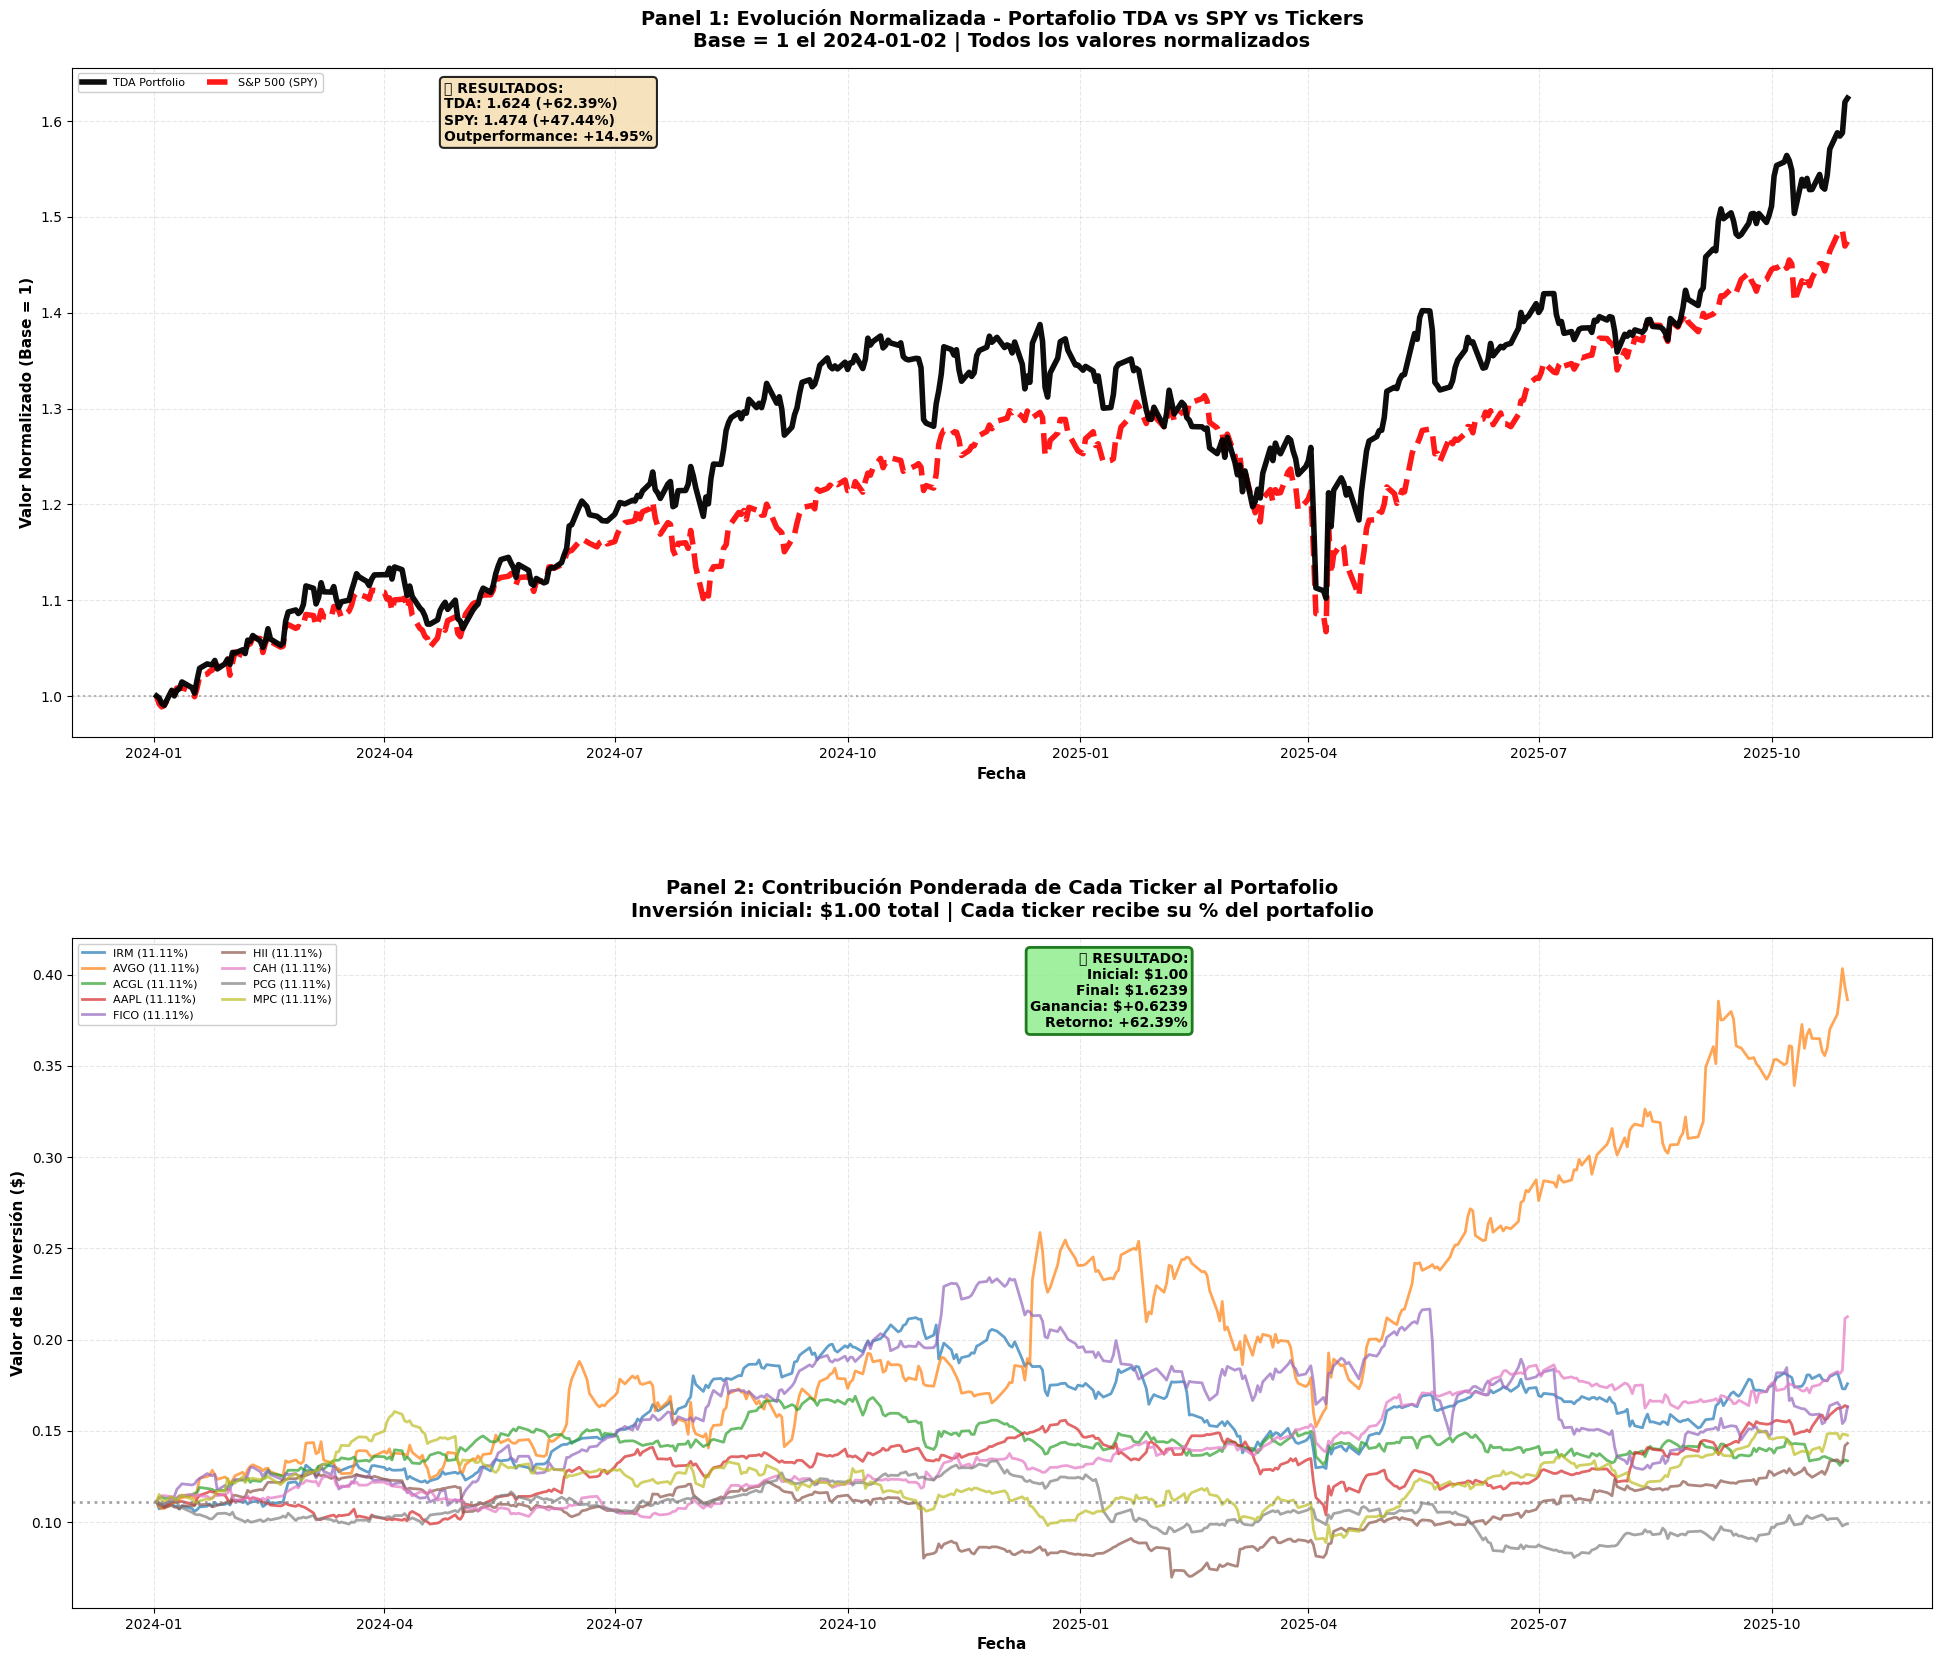


📊 RESUMEN CONSOLIDADO DE VALIDACIÓN:
   Período: 2024-01-02 a 2025-10-31
   Días de trading: 461
   Tickers en portafolio: 9

   💰 INVERSIÓN:
      Inicial: $1.00
      Final: $1.6239
      Ganancia: $+0.6239
      Retorno: +62.39%

   📈 vs SPY:
      TDA Portfolio: +62.39%
      S&P 500 (SPY): +47.44%
      Outperformance: +14.95%


In [24]:
# =======================================================
# 📊 GRÁFICAS CONSOLIDADAS DE VALIDACIÓN (OUT-OF-SAMPLE)
# =======================================================

print("\n" + "="*80)
print("📊 VISUALIZACIÓN COMPLETA DEL PERÍODO DE VALIDACIÓN")
print("="*80)

# Preparar datos de validación
validation_tickers = [t for t in portfolio_weights.keys() if t in validation_data.columns]
validation_prices = validation_data[validation_tickers].copy()
spy_validation_prices = SPY_validation['SPY'].copy()

print(f"\n📋 Información:")
print(f"   Período: {validation_data.index[0].strftime('%Y-%m-%d')} a {validation_data.index[-1].strftime('%Y-%m-%d')}")
print(f"   Tickers disponibles: {len(validation_tickers)}/{len(portfolio_weights)}")
print(f"   Días de trading: {len(validation_data)}")

# =======================================================================
# CREAR FIGURA CON 3 PANELES
# =======================================================================
fig = plt.figure(figsize=(24, 20))
gs = fig.add_gridspec(2, 1, hspace=0.3)

# =======================================================================
# PANEL 1: PORTAFOLIO vs SPY vs TICKERS (BASE = 1)
# =======================================================================
ax1 = fig.add_subplot(gs[0, 0])

print(f"\n📊 Panel 1: Evolución Normalizada")

# Normalizar todos los tickers a base 1
#colors = plt.cm.tab20(np.linspace(0, 1, len(validation_tickers)))
#for i, ticker in enumerate(validation_tickers):
#    ticker_normalized = validation_prices[ticker] / validation_prices[ticker].iloc[0]
#    ax1.plot(validation_prices.index, ticker_normalized, 
#            alpha=0.5, linewidth=1.5, color=colors[i],
#            label=f'{ticker}' if len(validation_tickers) <= 15 else '')

# Calcular portafolio TDA normalizado
weights_array = np.array([portfolio_weights[t] for t in validation_tickers])
validation_normalized = validation_prices / validation_prices.iloc[0]
portfolio_validation_normalized = (validation_normalized.values * weights_array).sum(axis=1)

# Graficar portafolio TDA
ax1.plot(validation_prices.index, portfolio_validation_normalized, 
        linewidth=4, color='black', label='TDA Portfolio', alpha=0.95, zorder=100)

# Graficar SPY normalizado
spy_normalized_val = spy_validation_prices / spy_validation_prices.iloc[0]
ax1.plot(spy_validation_prices.index, spy_normalized_val, 
        linewidth=4, color='red', linestyle='--', label='S&P 500 (SPY)', alpha=0.9, zorder=99)

# Configuración Panel 1
ax1.axhline(y=1.0, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
ax1.set_title('Panel 1: Evolución Normalizada - Portafolio TDA vs SPY vs Tickers\n' +
             f'Base = 1 el {validation_data.index[0].strftime("%Y-%m-%d")} | Todos los valores normalizados', 
             fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Fecha', fontsize=11, fontweight='bold')
ax1.set_ylabel('Valor Normalizado (Base = 1)', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Leyenda Panel 1
if len(validation_tickers) <= 15:
    ax1.legend(fontsize=8, loc='upper left', ncol=3, framealpha=0.95)
else:
    handles = [
        plt.Line2D([0], [0], color='black', linewidth=4, label='TDA Portfolio'),
        plt.Line2D([0], [0], color='red', linewidth=4, linestyle='--', label='S&P 500 (SPY)'),
        plt.Line2D([0], [0], color='gray', linewidth=1.5, alpha=0.5, 
                   label=f'{len(validation_tickers)} Tickers Individuales')
    ]
    ax1.legend(handles=handles, fontsize=10, loc='upper left', framealpha=0.95)

# Métricas Panel 1
final_portfolio = portfolio_validation_normalized[-1]
final_spy = spy_normalized_val.iloc[-1]
ret_portfolio = (final_portfolio - 1) * 100
ret_spy = (final_spy - 1) * 100
outperformance = ret_portfolio - ret_spy

textstr = f'📊 RESULTADOS:\n'
textstr += f'TDA: {final_portfolio:.3f} ({ret_portfolio:+.2f}%)\n'
textstr += f'SPY: {final_spy:.3f} ({ret_spy:+.2f}%)\n'
textstr += f'Outperformance: {outperformance:+.2f}%'

ax1.text(0.2, 0.98, textstr, transform=ax1.transAxes, fontsize=10,
       verticalalignment='top', fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85, edgecolor='black', linewidth=1.5))

# =======================================================================
# PANEL 2: TICKERS PONDERADOS - CONTRIBUCIÓN AL PORTAFOLIO
# =======================================================================
ax2 = fig.add_subplot(gs[1, 0])

print(f"📊 Panel 2: Contribución Ponderada")
print(f"\n💰 Simulación de inversión:")
print(f"   Si inviertes $1.00 total en el portafolio al inicio de validación:")

# Calcular contribución de cada ticker (normalizado × peso)
portfolio_contributions = {}
for ticker in validation_tickers:
    ticker_normalized = validation_prices[ticker] / validation_prices[ticker].iloc[0]
    ticker_weight = portfolio_weights[ticker]
    contribution = ticker_normalized * ticker_weight
    portfolio_contributions[ticker] = contribution
    
    # Graficar
    ax2.plot(validation_prices.index, contribution, 
            alpha=0.7, linewidth=2,
            label=f'{ticker} ({ticker_weight*100:.2f}%)')
    
    # Imprimir resumen
    valor_inicial = ticker_weight
    valor_final = contribution.iloc[-1]
    ret_pct = (valor_final / valor_inicial - 1) * 100
    print(f"   • {ticker:5s}: ${valor_inicial:.4f} → ${valor_final:.4f} ({ret_pct:+.2f}%)")

# Portafolio total
portfolio_total = sum(portfolio_contributions.values())

# Línea de referencia
ax2.axhline(y=1.0/len(validation_tickers), color='gray', linestyle=':', linewidth=2, alpha=0.7)

# Configuración Panel 2
ax2.set_title('Panel 2: Contribución Ponderada de Cada Ticker al Portafolio\n' +
             'Inversión inicial: $1.00 total | Cada ticker recibe su % del portafolio',
             fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Fecha', fontsize=11, fontweight='bold')
ax2.set_ylabel('Valor de la Inversión ($)', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')

# Leyenda Panel 2
if len(validation_tickers) <= 12:
    ax2.legend(fontsize=8, loc='upper left', ncol=2, framealpha=0.95)
else:
    handles = [
        plt.Line2D([0], [0], color='gray', linewidth=2, linestyle=':', 
                  label=f'{len(validation_tickers)} Tickers (ponderados)')
    ]
    ax2.legend(handles=handles, fontsize=10, loc='upper left', framealpha=0.95)

# Métricas Panel 2
valor_final_total = portfolio_total.iloc[-1]
ganancia_total = valor_final_total - 1.0
ret_total = (valor_final_total - 1.0) * 100

textstr2 = f'💰 RESULTADO:\n'
textstr2 += f'Inicial: $1.00\n'
textstr2 += f'Final: ${valor_final_total:.4f}\n'
textstr2 += f'Ganancia: ${ganancia_total:+.4f}\n'
textstr2 += f'Retorno: {ret_total:+.2f}%'

ax2.text(0.6, 0.98, textstr2, transform=ax2.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.85, 
                 edgecolor='darkgreen', linewidth=2))

# =======================================================================
# PANEL 3: COMPOSICIÓN PORCENTUAL (ÁREAS APILADAS)
# =======================================================================
'''ax3 = fig.add_subplot(gs[2, 0])

print(f"📊 Panel 3: Composición Porcentual")

# Crear matriz para área apilada
contributions_matrix = pd.DataFrame(portfolio_contributions)
contributions_pct = contributions_matrix.div(contributions_matrix.sum(axis=1), axis=0) * 100

# Graficar áreas apiladas
ax3.stackplot(contributions_pct.index, 
             *[contributions_pct[ticker] for ticker in validation_tickers],
             labels=validation_tickers if len(validation_tickers) <= 12 else None,
             alpha=0.7)

# Configuración Panel 3
ax3.set_title('Panel 3: Composición Porcentual del Portafolio en el Tiempo\n' +
             '¿Qué % del valor total aporta cada ticker?',
             fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel('Fecha', fontsize=11, fontweight='bold')
ax3.set_ylabel('Porcentaje del Portafolio Total (%)', fontsize=11, fontweight='bold')
ax3.set_ylim(0, 100)
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')

if len(validation_tickers) <= 12:
    ax3.legend(loc='upper left', ncol=3, fontsize=8, framealpha=0.9)

# Título general
fig.suptitle('ANÁLISIS COMPLETO DEL PERÍODO DE VALIDACIÓN (OUT-OF-SAMPLE)', 
             fontsize=18, fontweight='bold', y=0.995)
'''
plt.tight_layout()
plt.show()

# Resumen final consolidado
print(f"\n" + "="*80)
print(f"📊 RESUMEN CONSOLIDADO DE VALIDACIÓN:")
print(f"="*80)
print(f"   Período: {validation_data.index[0].strftime('%Y-%m-%d')} a {validation_data.index[-1].strftime('%Y-%m-%d')}")
print(f"   Días de trading: {len(validation_data)}")
print(f"   Tickers en portafolio: {len(validation_tickers)}")
print(f"\n   💰 INVERSIÓN:")
print(f"      Inicial: $1.00")
print(f"      Final: ${valor_final_total:.4f}")
print(f"      Ganancia: ${ganancia_total:+.4f}")
print(f"      Retorno: {ret_total:+.2f}%")
print(f"\n   📈 vs SPY:")
print(f"      TDA Portfolio: {ret_portfolio:+.2f}%")
print(f"      S&P 500 (SPY): {ret_spy:+.2f}%")
print(f"      Outperformance: {outperformance:+.2f}%")

